# **KurtoRank v3: An Unsupervised Ensemble Strategy for Subtype Annotation in Gene-Limited Spatial Transcriptomics**


**Chao Hui Huang**

This document describes the procedure of performming quality control (QC) and cell subtype annotation on Xenium data. The QC includes the considerations of both standard single-cell metrics and spatial-specific metrics.

The annotation approach is based on Pfizer in-house developed KurtoRank, an unsupervised ensemble strategy for cell subtype annotation in gene-limited spatial transcriptomics method, aiming to integrate multiple cell annotation approaches by kurtosis-based weight assignment for each method.

## **High-Quality Xenium Data Should Show:**
1. **Consistent Distributions:**
    * Smooth, unimodal distributions for key metrics
    * Few outliers in UMI counts and gene counts
    * Low background (negative probe) counts

2. **Good Segmentation Quality:**
    * Reasonable nucleus and cell areas
    * Consistent nucleus-to-cell ratio
    * No spatial artifacts in segmentation metrics

3. **Strong Signal-to-Noise:**
    * High contrast between actual signal and background
    * Spatial correlation of known marker genes
    * Clear tissue structure visible in marker gene expression

4. **Biological Plausibility:**
    * Expected marker genes showing tissue-specific patterns
    * Spatial autocorrelation of tissue-specific genes
    * Clustering that reveals known cell types in expected proportions
      
## **Key QC Criteria to Consider**
1. **Basic Cell Metrics:**
    * **Total counts:** 100-500 minimum for Xenium, 4000-6000 for Xenium5K (Xenium is typically lower than scRNA-seq)
    * **Genes detected:** 50-200 minimum for Xenium, 2000-3000 for Xenium5K
    * **Cells passing filters:** Typically 70-90% of cells should pass QC

2. **Xenium-Specific Metrics:**
    * **Signal-to-noise ratio:** > 0.8 is good, < 0.5 is concerning
    * **Nucleus-to-cell ratio:** Between 0.1 and 0.9 (extreme values indicate segmentation issues)
    * **Control probe counts:** Should be consistent across tissue
    * **Negative probe counts:** Should be low and evenly distributed

3. **Spatial Patterns:**
    * **patial gradients:** Look for artifacts in QC metrics (edges, corners, spots)
    * **Tissue coverage:** Cell density should match expectations for the tissue type
    * **Spatial autocorrelation:** Known tissue markers should show spatial correlation

## **1. Standard Single-Cell QC Metrics**
### Load python pacages and the environment

In [1]:
# This block aims to load required packages, including scanpy et al. There are also some predefined variables here.

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
import os
import gc
from pathlib import Path
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import spatialdata as sd
from spatialdata_io import xenium
import anndata as ad
import scanpy as sc
import squidpy as sq
import torch
from torch.distributions import Chi2
from scipy.stats import norm, combine_pvalues, hypergeom, zscore, rankdata, kurtosis, fisher_exact, ks_2samp, pearsonr, chi2, spearmanr, rankdata, hypergeom
from scipy.spatial import cKDTree
from collections import Counter
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.contingency_tables import Table2x2
from joblib import Parallel, delayed, parallel_backend
from joblib.parallel import BatchCompletionCallBack
from multiprocessing import Lock
from tqdm.notebook import tqdm
import contextlib
from IPython.display import display, Javascript
import time
import math
import ipynbname 

# Set plotting settings
# sc.settings.set_figure_params(dpi=100, frameon=False)
# sc.settings.verbosity = 1

### Set the corresponding data file name and path
    * **xenium_path:** the xenium output directory of the sample.
    * **ipynb_name:** this notebook file name
    * **report_name:** the report (HTML) to be generated

In [2]:
# Here we define xenium data path (the ``out'' or ``output'' folders generated by Xenium platform), ipynb file (this file) and report file.

xenium_path="/workspace/pan-tissue/xenium/breast/FFPE Human Breast using the Entire Sample Area/Replicate 2/outs"
ipynb_name = ipynbname.path().stem

print(f'xenium_path: {xenium_path}')
print(f'ipynb_name: {ipynb_name}.ipynb')
print(f'report_name: {ipynb_name}.html')

xenium_path: /workspace/pan-tissue/xenium/breast/FFPE Human Breast using the Entire Sample Area/Replicate 2/outs
ipynb_name: kurtorank-v2.ipynb
report_name: kurtorank-v2.html


### Defining sample disease type
    **disease_type:** 'prostate', 'breast', 'bladder', 'colorectal', 'liver'.

In [ ]:
# Here we define the disease type. This is for constructing cell marker gene sets for the specific cell types.

disease_type = 'breast'
common_only = True
normal_only = False
# v3 fix: after rank_markers.py reorders markers by atlas-derived
# specificity, set `use_top_k_markers` to truncate each subtype's
# marker list to the top-K most discriminative genes at load time.
# None = use the full (reordered) list. The pipeline still enforces
# the >=3 marker minimum downstream.
use_top_k_markers = None
chosen_leiden_res = 0.5
use_graphclust = True

print(f'disease_type: {disease_type}')
print(f'Use common cell types only? {"YES" if common_only else "NO"}')
print(f'Exclude cancer cell types? {"YES" if normal_only else "NO"}')
# print(f'Use graphclust provided by Xenium by default? {"YES" if use_graphclust else "NO"}')
if use_graphclust:
    print(f'Use graphclust provided by Xenium for clustering.')
else:
    print(f'Use leiden resolution {chosen_leiden_res} for clustering.')


### Load previously generated qced.h5ad as needed

In [4]:
# If ``qced.h5ad'' exists, load it. We can then skip the part of loading spatial data. 

# Jump to `4. You shall not pass' if previously generated qced.h5ad is loaded

if os.path.exists(os.path.join(xenium_path, 'qced.h5ad')):
    adata = sc.read_h5ad(os.path.join(xenium_path, 'qced.h5ad'))
    print(adata)

AnnData object with n_obs × n_vars = 811864 × 280
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'graphclust', 'n_genes_by_counts', 'negative_probe_counts', 'control_probe_ratio', 'nucleus_area_ratio', 'signal_to_noise', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'spatialdata_attrs', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'counts'
    obsp: 'connectivities', 'distances'


In [5]:
# If ``raw.h5ad'' exists, load it. We can then skip the part of loading spatial data. 

# Jump to `3. Single-cell QC procedure' if previously generated qced.h5ad is loaded

if os.path.exists(os.path.join(xenium_path, 'raw.h5ad')):
    adata = sc.read_h5ad(os.path.join(xenium_path, 'raw.h5ad'))
    print(adata)

AnnData object with n_obs × n_vars = 885523 × 280
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'graphclust'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'


## **2. Obtain spatial data and show the structure**
### Load spatial data

In [6]:
# Using spatialdata_io.xenium() loading the xenium data (from the ``out'' or ``output'' folder generated by xenium platform) 

sdata = xenium(xenium_path)
sdata

/opt/anaconda3/envs/spatial/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object
├── Images
│     ├── 'morphology_focus': DataTree[cyx] (1, 111225, 51458), (1, 55612, 25729), (1, 27806, 12864), (1, 13903, 6432), (1, 6951, 3216)
│     └── 'morphology_mip': DataTree[cyx] (1, 111225, 51458), (1, 55612, 25729), (1, 27806, 12864), (1, 13903, 6432), (1, 6951, 3216)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (111225, 51458), (55612, 25729), (27806, 12864), (13903, 6432), (6951, 3216)
│     └── 'nucleus_labels': DataTree[yx] (111225, 51458), (55612, 25729), (27806, 12864), (13903, 6432), (6951, 3216)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (885523, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (885523, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (885523, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (885523, 280)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images)

### Extract the AnnData table from spatial data

In [7]:
# Make a copy of the adata embedded inside of xenium spatial data. 

adata = sdata.tables['table'].copy()
adata

AnnData object with n_obs × n_vars = 885523 × 280
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

### Load Xenium default gene_expression_graphclust

In [8]:
# Perform a required step of loafing default graphclust made by xenium platform. spatialdata_io.xenium() doesn't do this.

graphclust_csv = os.path.join(xenium_path, 'analysis/clustering/gene_expression_graphclust/clusters.csv')
graphclust_df = pd.read_csv(graphclust_csv, dtype={'Cluster': str})
graphclust_dict = dict(zip(graphclust_df['Barcode'], graphclust_df['Cluster']))
adata.obs['graphclust'] = adata.obs.cell_id.map(graphclust_dict).astype('category')
print(adata.obs['graphclust'])

0          4
1          1
2          1
3          1
4          7
          ..
885518    12
885519    12
885520     7
885521     2
885522    10
Name: graphclust, Length: 885523, dtype: category
Categories (21, object): ['1', '10', '11', '12', ..., '6', '7', '8', '9']


### Save raw data

In [9]:
# Save raw data to ``out'' or ``output'' folder generated by Xenium platform

adata.write_h5ad(os.path.join(xenium_path, 'raw.h5ad'))
adata

AnnData object with n_obs × n_vars = 885523 × 280
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'graphclust'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

## **3. Single-cell QC procedure**
Note that the data doesn't have mitochondrial genes, as a result, MT- based QC won't be included.

In [ ]:
# Validing the availabilities of data fields in the obtained adata.

# Calculate and generate standard QC metrics
sc.pp.calculate_qc_metrics(
    adata, 
    # percent_top=(10, 20, 50, 100, 200, 500),
    percent_top=None,
    log1p=False,
    inplace=True
)

# Add Xenium-specific metrics (if not already present)
if 'nucleus_area' not in adata.obs:
    print('These would come from the cells.csv file.')
    print('You might need to merge them in manually if not using the squidpy reader.')
    pass
 
# Focus genes - genes of high interest in your panel
# Calculate percentage of counts from focus genes if you have a predefined panel

if 'focus_gene' in adata.var:
    adata.obs['pct_counts_focus'] = (
        np.sum(adata[:, adata.var['focus_gene']].X, axis=1) / 
        np.sum(adata.X, axis=1) * 100
    )

# Nucleus metrics (available in Xenium output)
xenium_metrics = [
    'nucleus_area',        # Size of the nucleus
    'cell_area',           # Size of the cell
    'control_probe_counts', # Control probe counts
    'control_codeword_counts', # Control codeword counts
    'fov_name',            # Field of view
    'transcript_counts',    # Total transcript count
    'negative_probe_counts' # Negative control count
]

# v3 fix: v2 set negative_probe_counts := control_probe_counts, which
# conflates two distinct Xenium QC fields. The spatialdata_io reader
# already exposes `control_probe_counts` (negative DNA probes) and
# `control_codeword_counts` (negative decoding codewords) separately.
# We preserve `negative_probe_counts` only if it was provided by the
# reader; otherwise we derive signal-to-noise from control_probe_counts
# directly and label it accordingly.
if "negative_probe_counts" not in adata.obs.columns:
    # Fall back: treat negative-probe background = control-probe counts.
    # Keep a flag so downstream code / plots can disclose the fallback.
    adata.obs["negative_probe_counts"] = adata.obs["control_probe_counts"]
    adata.uns["snr_source"] = "control_probe_counts (fallback)"
else:
    adata.uns["snr_source"] = "negative_probe_counts"

adata.obs["control_probe_ratio"] = (
    adata.obs["control_probe_counts"] / adata.obs["total_counts"]
)
adata.obs["nucleus_area_ratio"] = (
    adata.obs["nucleus_area"] / adata.obs["cell_area"]
)
adata.obs["signal_to_noise"] = (
    (adata.obs["transcript_counts"] - adata.obs["negative_probe_counts"]) /
    adata.obs["transcript_counts"]
).fillna(0)
print(f"signal_to_noise source: {adata.uns['snr_source']}")

# Ensure these metrics are in adata.obs (they should be in the cells.csv file)
missing_metrics = [m for m in xenium_metrics if m not in adata.obs]

if missing_metrics:
    print(f"Missing Xenium metrics: {missing_metrics}")
    # You would need to merge these from the cells.csv file

### Percentage of negative counts

In [11]:
# Evaluate the percentage of negative counts

cprobes = (
    adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
cwords = (
    adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")

Negative DNA probe count % : 0.003150845091517389
Negative decoding count % : 0.00305612828991757


### Assessment of Spatial Data
#### Histograms of spatial data

0it [00:00, ?it/s]

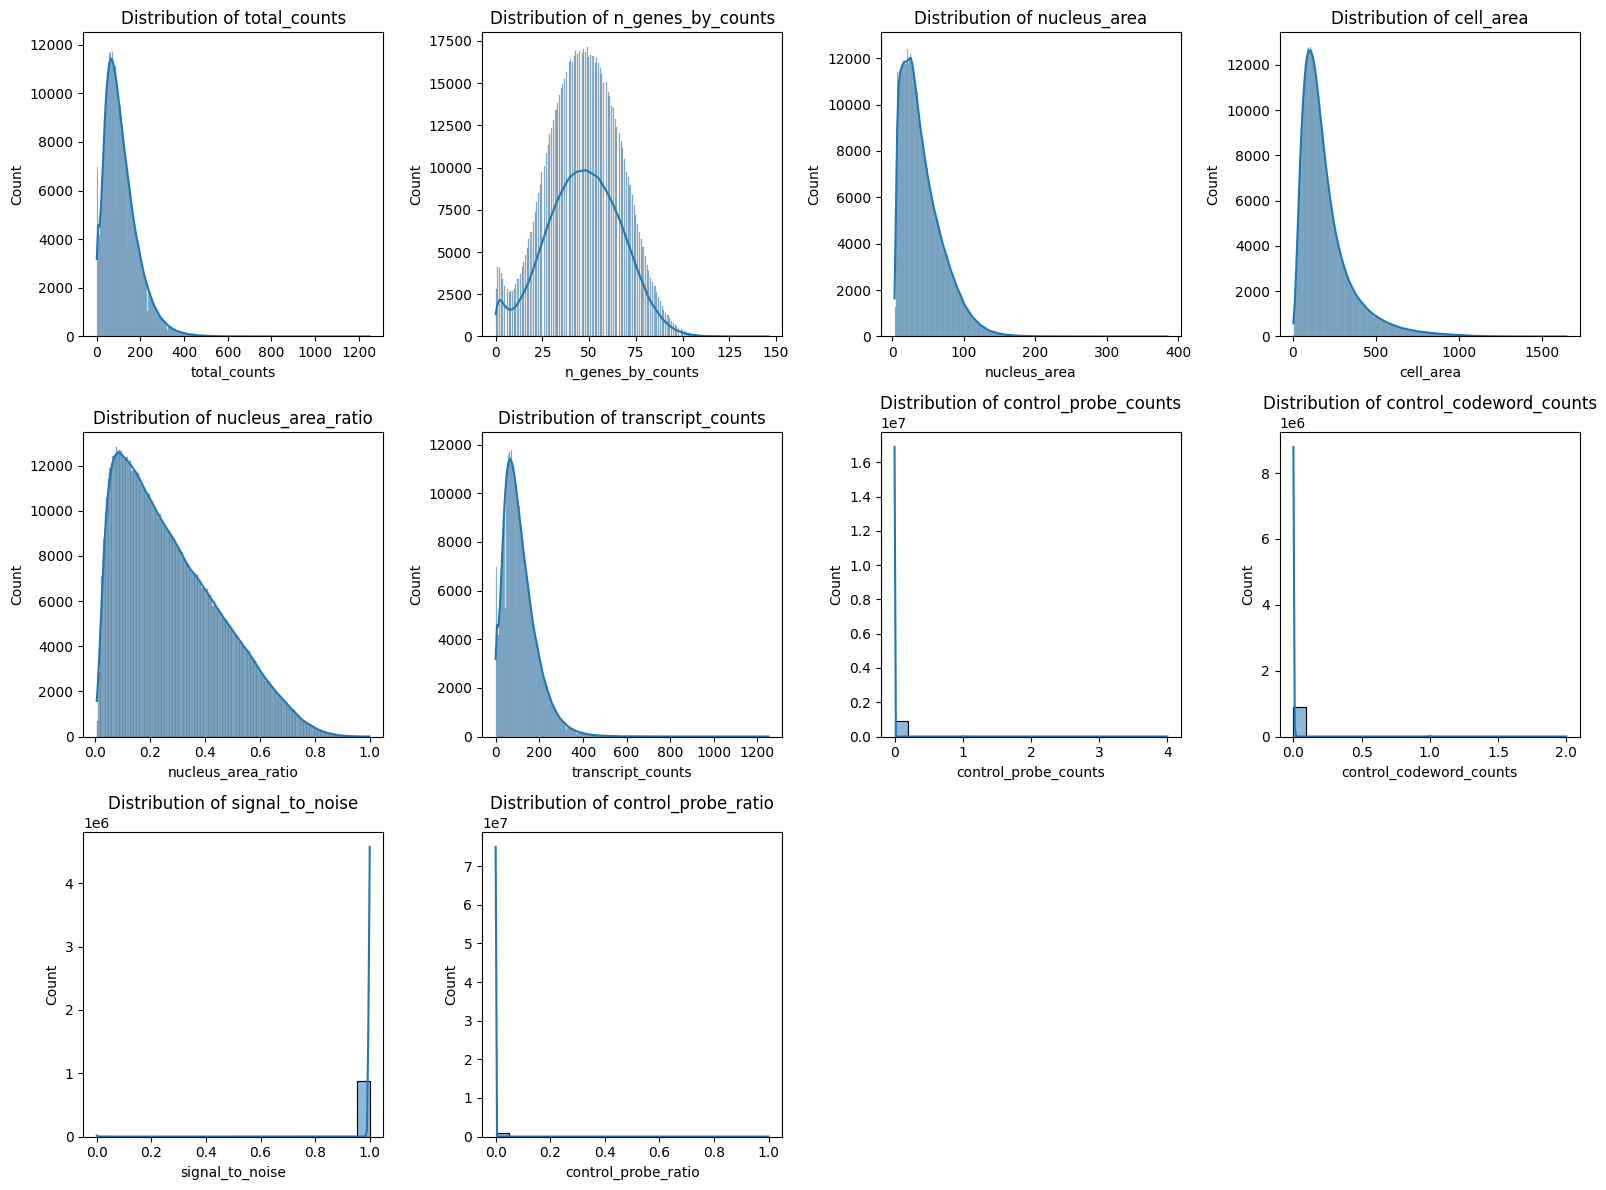

In [12]:
# Obtaining histograms of spatial data for investigating the data quality visually.

available_obs = ['total_counts',
                 'n_genes_by_counts',
                 'nucleus_area',
                 'cell_area',
                 'nucleus_area_ratio',
                 'transcript_counts',
                 'control_probe_counts',
                 'control_codeword_counts',
                 'signal_to_noise', 
                 'control_probe_ratio']
if available_obs:
    fig_cols = int(np.ceil(np.sqrt(len(available_obs))))
    fig_rows = int(np.ceil(len(available_obs)/fig_cols))
    fig, axs = plt.subplots(fig_rows, fig_cols, figsize=(4*fig_cols, 4*fig_rows))

    for ax_r in range(fig_rows):
        for ax_c in range(fig_cols):
            axs[ax_r, ax_c].set_visible(False)
    
    if len(available_obs) == 1:
        axs = [axs]

    for i, obs in tqdm(enumerate(available_obs)):
        ax_r = int(np.floor(i / fig_cols))
        ax_c = int(i % fig_cols)

        sns.histplot(adata.obs[obs], kde=True, ax=axs[ax_r,ax_c])
        axs[ax_r,ax_c].set_title(f'Distribution of {obs}')
        axs[ax_r,ax_c].set_xlabel(obs)
        axs[ax_r,ax_c].set_visible(True)
        
    plt.tight_layout()
    plt.show()

#### Investigating the QC data using SpatialPlot

0it [00:00, ?it/s]

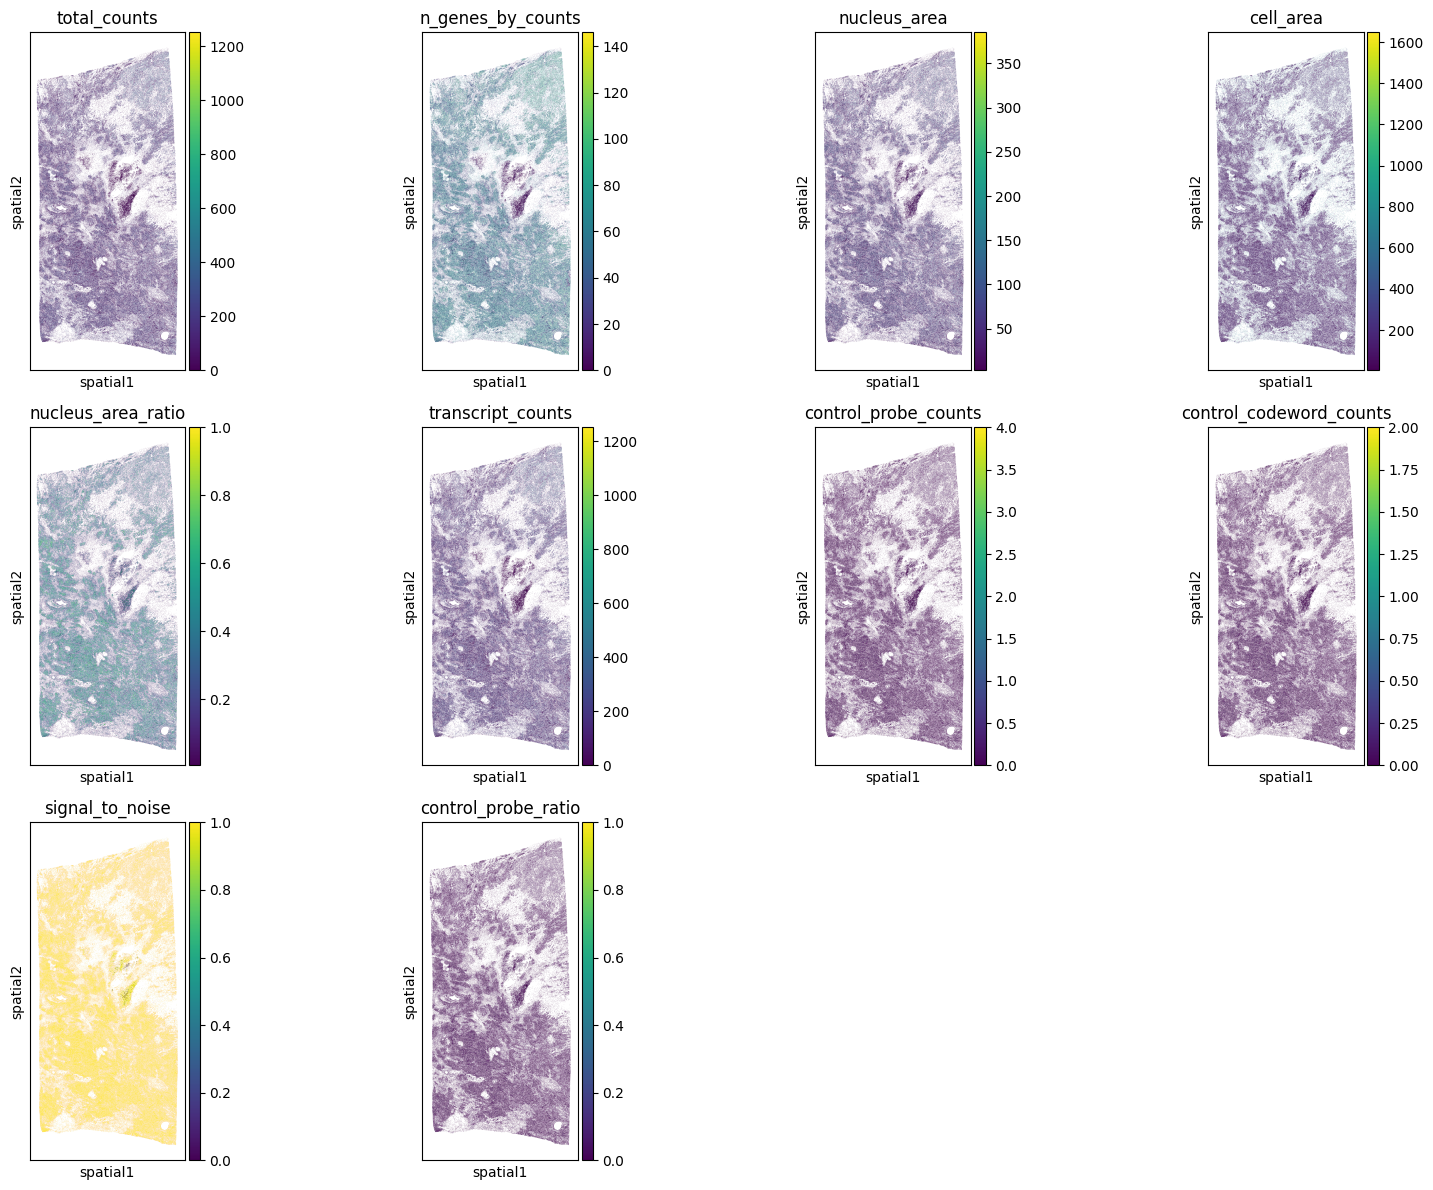

In [13]:
# SpatialPlot of spatial data

if available_obs:
    fig_cols = int(np.ceil(np.sqrt(len(available_obs))))
    fig_rows = int(np.ceil(len(available_obs)/fig_cols))
    fig, axs = plt.subplots(fig_rows, fig_cols, figsize=(4*fig_cols, 4*fig_rows))

    for ax_r in range(fig_rows):
        for ax_c in range(fig_cols):
            axs[ax_r, ax_c].set_visible(False)
            
    if len(available_obs) == 1:
        axs = [axs]

    for i, obs in tqdm(enumerate(available_obs)):
        ax_r = int(np.floor(i / fig_cols))
        ax_c = int(i % fig_cols)

        sc.pl.spatial(
           adata,
           color=obs,
           size=10,
           ax=axs[ax_r,ax_c],
           show=False,
           spot_size=1,
           title=obs
        )

        axs[ax_r, ax_c].set_visible(True)
        
    plt.tight_layout()
    plt.show()

### Filtering for QC
#### Minimal number of genes and cells

In [14]:
# Here we define the minimal counts of genes and cells.

min_genes = 10 # 10
min_cells = 5 # 5

print(f'min_genes: {min_genes}, min_cells: {min_cells}')

min_genes: 10, min_cells: 5


#### Percentile for filtering

In [15]:
# Define the higher and lower percentages in order to remve the outliers.

lower_percentile = 1
upper_percentile = 99

print(f'lower_percentile: {lower_percentile}, upper_percentile: {upper_percentile}')

lower_percentile: 1, upper_percentile: 99


#### Filtering

In [16]:
# Below will implement the above defined filtering criteria. We first, keep the raw data.

adata.raw = adata.copy()
original_cells = adata.n_obs

In [ ]:
# Filter by above defined minimmal genes and cells.

# v3 fix: `min_genes` semantically means minimum genes per cell; v2 used
# `min_counts` here, which instead filters by total UMI counts.
sc.pp.filter_cells(adata, min_genes=min_genes)
sc.pp.filter_genes(adata, min_cells=min_cells)

In [18]:
# Filter by transcript count (adjust thresholds based on your data) (CURRENTLY DISABLED)

# ratio_min = np.percentile(adata.obs['control_probe_ratio'], lower_percentile)  
# ratio_max = np.percentile(adata.obs['control_probe_ratio'], upper_percentile) 
# print(f"Control probe ratio range: {ratio_min:.1f} - {ratio_max:.1f}")
# adata = adata[(adata.obs['control_probe_ratio'] >= ratio_min) & 
#               (adata.obs['control_probe_ratio'] <= ratio_max)].copy()

In [19]:
# Filter by transcript count (adjust thresholds based on your data)

if lower_percentile > 0 or upper_percentile < 100:
    count_min = np.percentile(adata.obs['total_counts'], lower_percentile)  
    count_max = np.percentile(adata.obs['total_counts'], upper_percentile) 
    print(f"Transcript count range: {count_min:.1f} - {count_max:.1f}")
    adata = adata[(adata.obs['total_counts'] >= count_min) & 
                  (adata.obs['total_counts'] <= count_max)].copy()

Transcript count range: 14.0 - 358.0


In [20]:
# Filter by number of genes detected

if lower_percentile > 0 or upper_percentile < 100:
    genes_min = np.percentile(adata.obs['n_genes_by_counts'], lower_percentile)
    genes_max = np.percentile(adata.obs['n_genes_by_counts'], upper_percentile)
    print(f"Genes detected range: {genes_min:.1f} - {genes_max:.1f}")
    adata = adata[(adata.obs['n_genes_by_counts'] >= genes_min) & 
                  (adata.obs['n_genes_by_counts'] <= genes_max)].copy()

Genes detected range: 13.0 - 89.0


In [21]:
# Filter by nucleus_area

adata = adata[adata.obs['nucleus_area'].notna()].copy()

if lower_percentile > 0 or upper_percentile < 100:
    area_min = np.percentile(adata.obs['nucleus_area'], lower_percentile)
    area_max = np.percentile(adata.obs['nucleus_area'], upper_percentile)
    print(f"Nucleus area range: {area_min:.1f} - {area_max:.1f}")
    adata = adata[(adata.obs['nucleus_area'] >= area_min) & 
                  (adata.obs['nucleus_area'] <= area_max)].copy()

Nucleus area range: 5.7 - 122.8


In [22]:
# Report cells removed

cells_kept = adata.n_obs
cells_removed = original_cells - cells_kept
percent_removed = (cells_removed / original_cells) * 100
print(f"Cells before filtering: {original_cells}")
print(f"Cells after filtering: {cells_kept}")
print(f"Cells removed: {cells_removed} ({percent_removed:.1f}%)")

Cells before filtering: 885523
Cells after filtering: 811864
Cells removed: 73659 (8.3%)


### Clustering for QC
#### Perform preprocessing

In [23]:
# Perform preprocessing, including normalize_total, log1p.

if "log1p" not in adata.uns:  # Check if normalization has been performed
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata,
                          target_sum=1e4, # default is 1e4, 5e4 for more permissive situation
                         )
    sc.pp.log1p(adata)

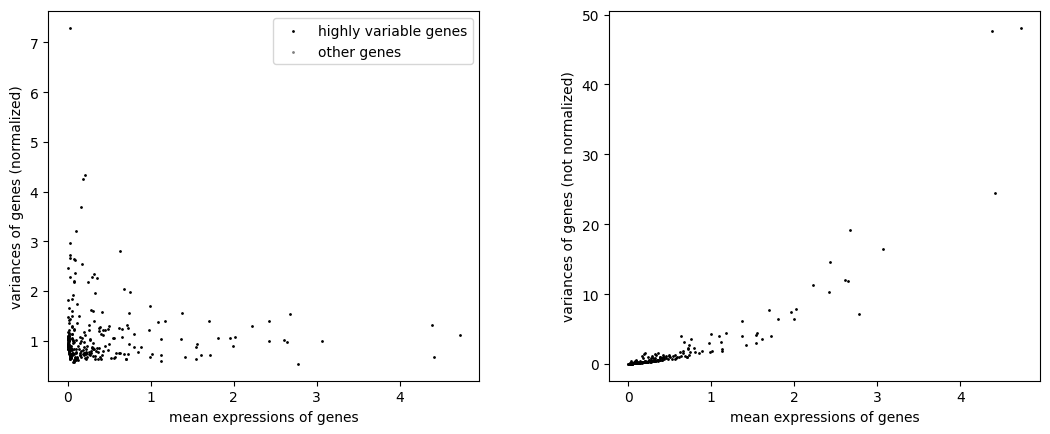

<Figure size 640x480 with 0 Axes>

In [24]:
# Perform highly_variable_genes. scale will be used in a copy of adata scince we want to keep the original gene counts for cell type annotation. 

sc.pp.highly_variable_genes(adata, 
                            flavor='seurat_v3',
                            layer="counts",
                            # min_mean=0.0125, # default is 0.0125, 0.005 for more permissive situation 
                            # max_mean=3, # default is 3, 5 for more permissive situation 
                            # min_disp=0.5, # default is 0.5, 0.3 for more permissive situation, useless if flavor='seurat_v3', 
                            n_top_genes=3500, # default is 2000, 3000 for more permissive situation or for marker gene annotation.
                           )
# adata = adata[:, adata.var.highly_variable].copy()  # Subset to highly variable genes
# sc.pp.scale(adata, max_value=10)

# Plot highly variable genes
sc.pl.highly_variable_genes(adata)

plt.tight_layout()
plt.show()

#### Perform dimensionality reduction and clustering

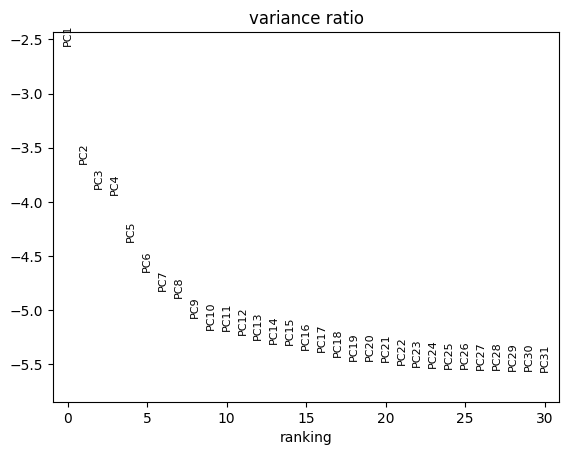

<Figure size 640x480 with 0 Axes>

In [25]:
# Now we do PCA on a copy of adata. This is for investigation and visualization purpose. Thus we make a copy of adata, perform PCA and copy the results back to adata.
if "X_pca" not in adata.obsm:
   adata_proc = adata[:, adata.var.highly_variable].copy()  # Subset to highly variable genes
   sc.pp.scale(adata_proc, max_value=10)
   sc.tl.pca(adata_proc, 
             # use_highly_variable=True, # Not necessary as this copy contains only highly_variable. 
             svd_solver='arpack',
            )
    
   adata.obsm['X_pca'] = adata_proc.obsm['X_pca']
   adata.uns['pca'] = adata_proc.uns['pca']
   # adata.varm['PCs'] = adata_proc.varm['PCs']

# Plot variance ratio to determine optimal number of PCs
sc.pl.pca_variance_ratio(adata, log=True)

plt.tight_layout()
plt.show()

#### Show 'total_counts', 'n_genes_by_counts' UMAPs

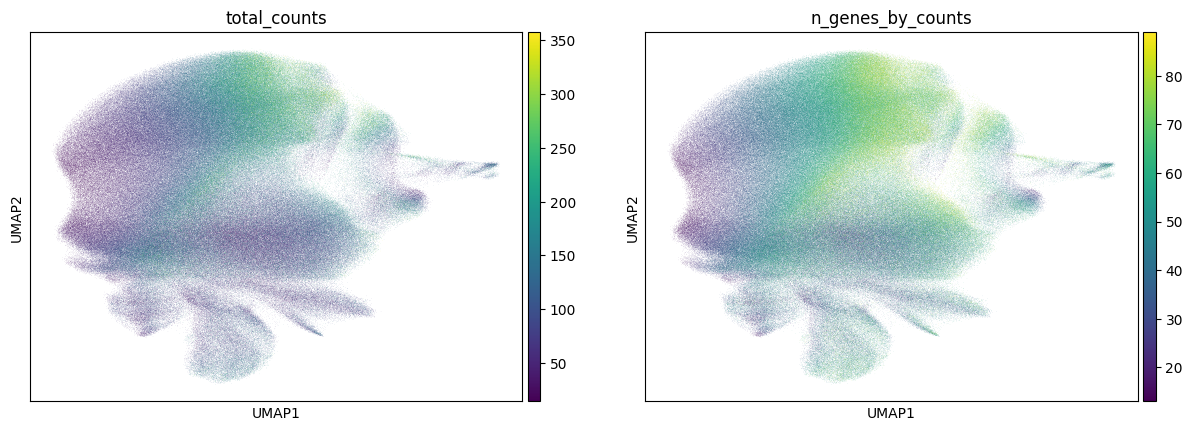

<Figure size 640x480 with 0 Axes>

In [26]:
# Perforem sc.pp.neighbors for UMAPs.

if "neighbors" not in adata.uns:
   sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30, use_rep='X_pca')

if "X_umap" not in adata.obsm:
   sc.tl.umap(adata)

sc.pl.umap(
    adata, 
    color=['total_counts', 'n_genes_by_counts'],
    use_raw=False, color_map='viridis',
)

plt.tight_layout()
plt.show()

#### Try different clustering resolutions

In [27]:
# Various leiden resolution will be used for determining the optimal leiden parameter. This step can be skipped if we are going to use ``graphclust'' provided by xenium platform.

leiden_resolutions = [0.8, 0.5, 1.2]

if not use_graphclust:
    for res in tqdm(leiden_resolutions):
        if f'leiden_res_{res}' not in adata.obs:
            # print(f"Performing leiden_res_{res}...")
            sc.tl.leiden(adata, resolution=res, key_added=f'leiden_res_{res}')
    
    sc.pl.umap(
        adata, 
        color=[f'leiden_res_{res}' for res in leiden_resolutions],
        show=False,
    )
    
    plt.tight_layout()
    plt.show()

### Save the QC'ed adata

In [28]:
# Save the QC'ed adata in the ``out'' or ``output'' folder provided by xenium platform.

adata.write_h5ad(os.path.join(xenium_path, 'qced.h5ad'))

## **4. You shall not pass!**
### Choose a primary clustering for downstream analysis
#### Visually inspect the leiden results, decide the resolution for the primary_cluster.

In [29]:
# Choose a primary clustering resolution for downstream analysis

# You can adjust this based on visual inspection of clusters
# chosen_leiden_res = 1.2
primary_cluster = f'leiden_res_{chosen_leiden_res}'

# Or, using the cluster as needed. 'graphclust' was obtained from QuST
if use_graphclust:
    primary_cluster = 'graphclust'

adata.obs['clusters'] = adata.obs[primary_cluster]

print(f'Chosen cluster: {primary_cluster}')

Chosen cluster: graphclust


#### Plot clustering results

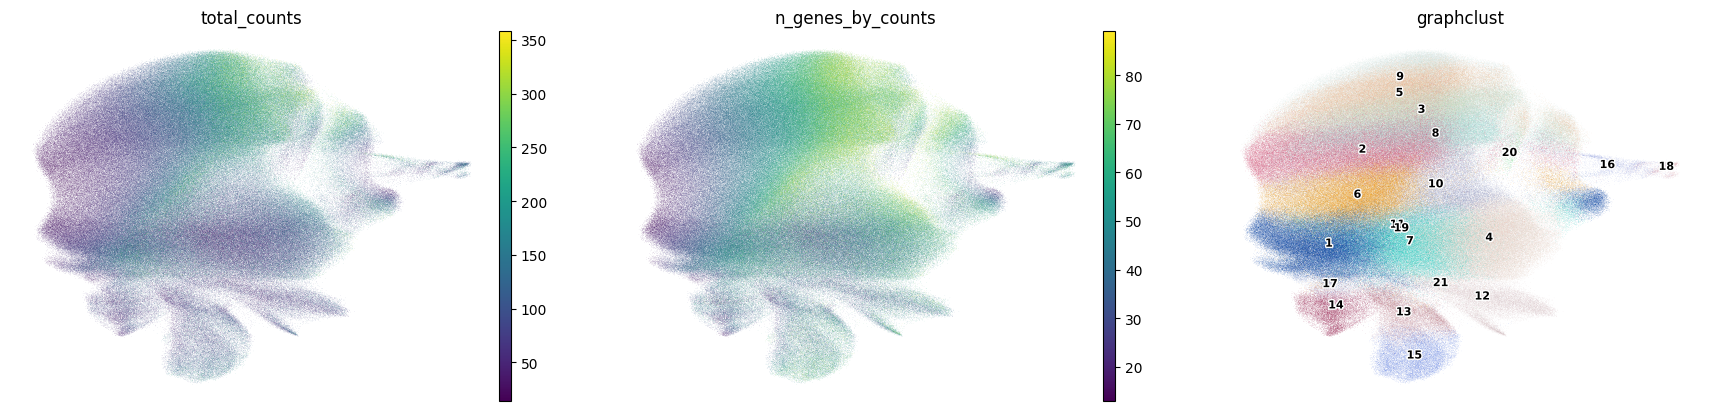

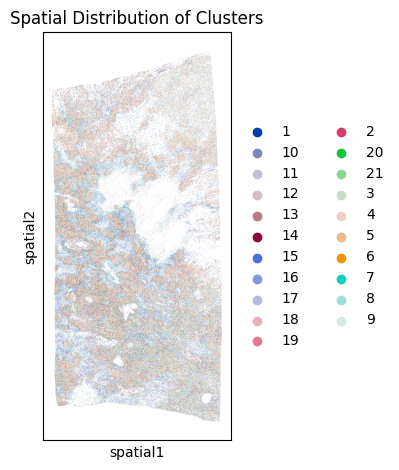

In [30]:
# Plot total_counts and n_genes_by_counts, and the mapped primary_cluster in order to identify the potential quality issues.

sc.pl.umap(
    adata, 
    color=[
        "total_counts",
        "n_genes_by_counts",
        primary_cluster,
    ],
    legend_loc='on data',
    legend_fontsize=8,
    legend_fontoutline=2,
    frameon=False,
    show=False,
)

sc.pl.spatial(
    adata, 
    color=primary_cluster, 
    size=10, 
    show=False,
    spot_size=1,
    title='Spatial Distribution of Clusters'
)

plt.tight_layout()
plt.show()

#### Spatial neighborhood analysis for QC

  0%|          | 0/1000 [00:00<?, ?/s]

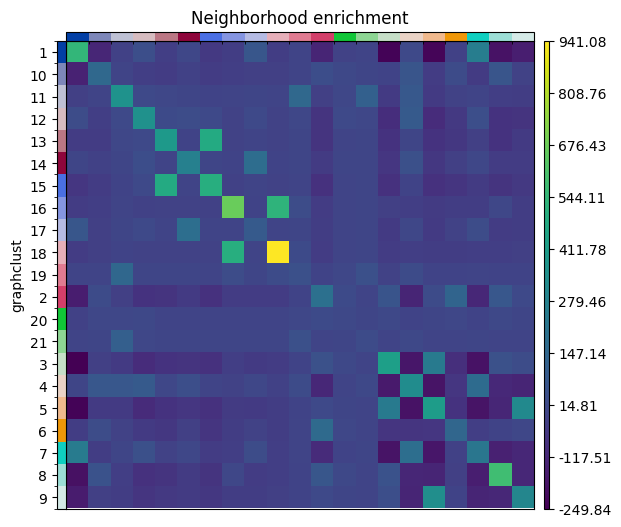

In [31]:
# 1) Make sure you already have your canonical order, e.g. from summary_df
# clusters_sorted = ['1', '2', '3', ...]  # same as you used in agreement heatmap

# 2) Ensure obs[primary_cluster] is string and categorical with that order
adata.obs[primary_cluster] = adata.obs[primary_cluster].astype(str)

# Only keep categories that actually exist in the data
# cluster_order = [c for c in clusters_sorted if c in adata.obs[primary_cluster].values]

adata.obs[primary_cluster] = pd.Categorical(
    adata.obs[primary_cluster],
    # categories=cluster_order,
    ordered=True,
)

# 3) Recompute neighbors + nhood_enrichment so Squidpy sees the new category order
sq.gr.spatial_neighbors(adata, coord_type="generic", spatial_key="spatial")
sq.gr.nhood_enrichment(adata, cluster_key=primary_cluster)

# 4) Plot with consistent cluster order (rows/cols follow categorical order)
sq.pl.nhood_enrichment(adata, cluster_key=primary_cluster, figsize=(5, 5))


## **5. Perform automated cell annotation**

### Define marker genes for both normal and cancer cell types

In [ ]:
# === 5.1 Load marker panel (v3 schema) ===
# v3 schema columns:
#   tissue_type, common, malignant, major_type, subtype,
#   pannuke_label, hne_type, hne_label, markers
# Notes:
#   - `malignant` replaces legacy `normal` (inverse polarity).
#   - `major_type`   replaces legacy `major`.
#   - `pannuke_label` replaces legacy `pannuke_type`.
# Keys use (tissue_type, subtype) to avoid cross-tissue name collisions
# (e.g. "Fibroblasts", "Endothelial cells" appear in several tissues).

all_markers_df = pd.read_csv('markers-v3.csv')
all_markers_df = all_markers_df[
    (all_markers_df.tissue_type == disease_type) |
    (all_markers_df.tissue_type == 'immune') |
    (all_markers_df.tissue_type == 'circulating')
]

if common_only:
    all_markers_df = all_markers_df[all_markers_df.common == True]
if normal_only:
    all_markers_df = all_markers_df[all_markers_df.malignant == False]

all_markers_df = all_markers_df.drop_duplicates(
    subset=['tissue_type', 'subtype'], keep='first'
).reset_index(drop=True)

cancer_markers = all_markers_df[all_markers_df.malignant == True]

# Use `subtype` as dict key (unique within a loaded panel after the
# filter above). If you ever broaden the filter, switch to
# (tissue_type, subtype) composite keys.
assert all_markers_df['subtype'].is_unique, (
    "Subtype names are not unique in the filtered panel; "
    "switch to composite (tissue_type, subtype) keys."
)

def _parse_markers(x):
    # Preserve ranked order from markers-v3.csv; dedupe while keeping order.
    seen, out = set(), []
    for g in x.split(','):
        g = g.strip()
        if g and g not in seen:
            seen.add(g); out.append(g)
    if use_top_k_markers is not None and use_top_k_markers > 0:
        out = out[:int(use_top_k_markers)]
    return out

all_markers = (
    all_markers_df
    .set_index('subtype')['markers']
    .apply(_parse_markers)
    .to_dict()
)

all_major_types       = all_markers_df.set_index('subtype')['major_type'].to_dict()
all_pannuke_types     = all_markers_df.set_index('subtype')['pannuke_label'].to_dict()
all_malignant_indicators = all_markers_df.set_index('subtype')['malignant'].astype(bool).to_dict()

_provenance_cols = [c for c in ('rank_source','low_support') if c in all_markers_df.columns]
print(f"Loaded {len(all_markers_df)} subtypes from markers-v3.csv "
      f"(tissue={disease_type}, common_only={common_only}, normal_only={normal_only}, "
      f"use_top_k_markers={use_top_k_markers})")
if _provenance_cols:
    print('rank provenance:')
    print(all_markers_df[_provenance_cols].value_counts(dropna=False).to_string())
    _low = all_markers_df[all_markers_df.get('low_support', False) == True]
    if len(_low):
        print(f'low_support subtypes ({len(_low)}):',
              ', '.join(_low['subtype'].tolist()[:10]),
              '...' if len(_low) > 10 else '')
all_markers_df


### Spatial autocorrelation

In [33]:
# === 5.2 空間自相關（Moran's I）檢查 marker 的空間 pattern ===
marker_genes = list({g for m in all_markers.values() for g in m})
available_markers = [gene for gene in marker_genes if gene in adata.var_names]

if len(available_markers) > 0:
    sq.gr.spatial_autocorr(
        adata,
        mode="moran",
        genes=available_markers
    )


### Plot autocorrelation results

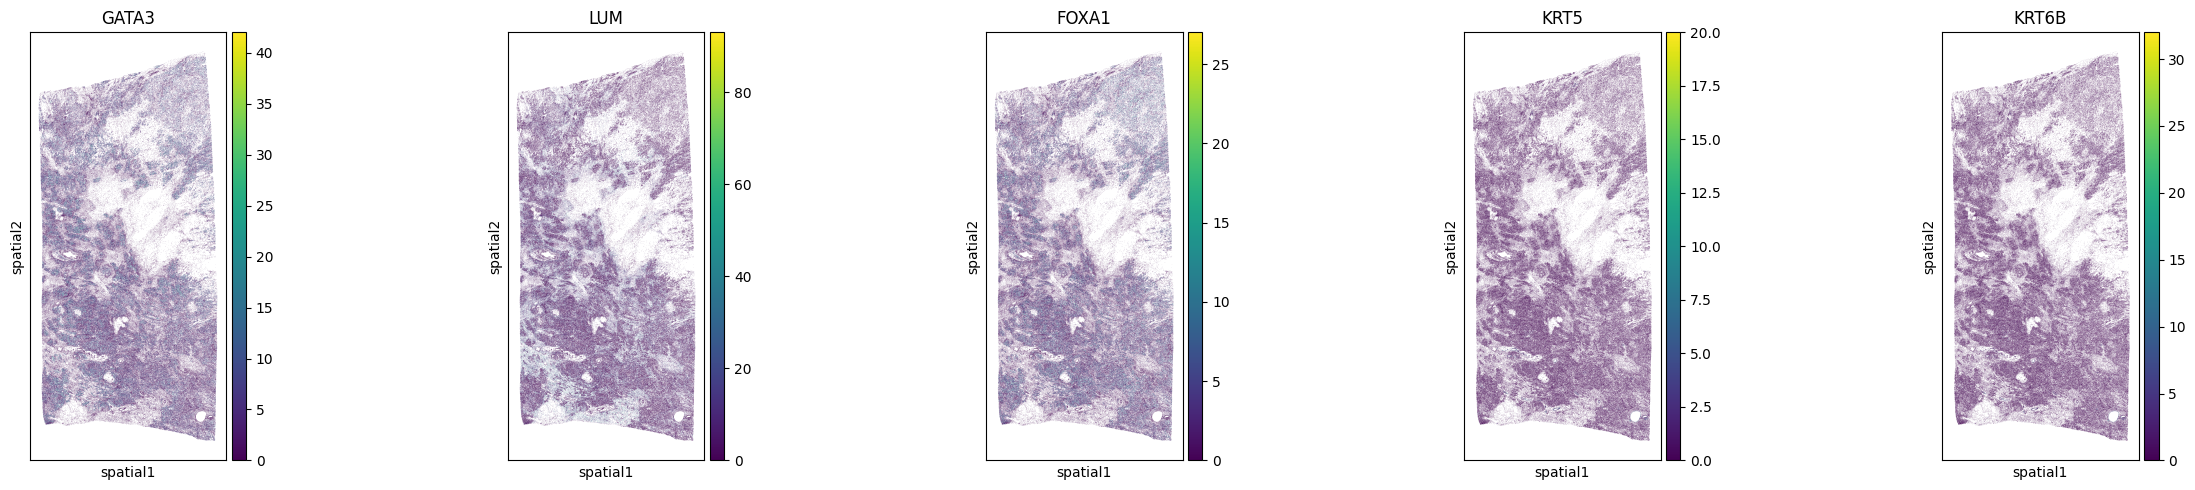

In [34]:
# Plot autocorrelation results

if len(available_markers) > 0:
    if 'moranI' in adata.uns:
        moran_scores = adata.uns['moranI']
        top_genes = moran_scores.sort_values('I', ascending=False).head(5)
        top_gene_names = top_genes.index.tolist()
    
        fig, axes = plt.subplots(1, len(top_gene_names), figsize=(5 * len(top_gene_names), 5))
        for i, gene in enumerate(top_gene_names):
            ax = axes[i] if len(top_gene_names) > 1 else axes
            sc.pl.spatial(
                adata,
                color=gene,
                size=10,
                img_key=None,
                ax=ax,
                spot_size=1,
                show=False
            )
        plt.tight_layout()
        plt.show()


### Aligning the marker genes and spatial data

In [35]:
# === 5.3 根據實際資料過濾 marker genes（只留有出現在 adata.var_names 的） ===
filtered_markers = {}
sum_marker_count = 0
for i, (cell_subtype, markers) in enumerate(all_markers.items()):
    existing_markers = [gene for gene in markers if gene in adata.var_names]
    if len(existing_markers) >= 2:  # 至少要 2 個 marker 才有意義
        filtered_markers[cell_subtype] = existing_markers
        sum_marker_count += len(existing_markers)
        print(f"{i+1}/{len(all_markers)} - {cell_subtype}: {len(existing_markers)}/{len(markers)} markers found")
    else:
        print(f"{i+1}/{len(all_markers)} - Warning: Not enough markers for {cell_subtype} found in dataset")

print(f'Average marker number: {sum_marker_count / max(len(all_markers), 1):.2f}')
all_markers = filtered_markers

cell_subtypes = list(all_markers.keys())

1/36 - Luminal A tumor cells: 10/54 markers found
2/36 - Luminal B tumor cells: 9/50 markers found
3/36 - HER2-enriched tumor cells: 5/54 markers found
4/36 - Basal-like tumor cells: 9/50 markers found
5/36 - Warning: Not enough markers for Neuroendocrine-like tumor cells found in dataset
6/36 - Fibroblasts: 10/50 markers found
7/36 - Adipocytes: 7/54 markers found
8/36 - Endothelial cells: 10/50 markers found
9/36 - Myoepithelial cells: 13/50 markers found
10/36 - CD4+ T cells: 17/50 markers found
11/36 - Naïve CD4+ T cells: 10/50 markers found
12/36 - Central-memory T cells (TCM): 12/50 markers found
13/36 - Effector-memory T cells (TEM): 14/50 markers found
14/36 - Effector-memory RA T cells (TEMRA): 17/50 markers found
15/36 - CD8+ T cells: 22/50 markers found
16/36 - Exhausted CD8+ T cells: 10/50 markers found
17/36 - Regulatory T cells (Tregs): 14/50 markers found
18/36 - T follicular helper (Tfh) cells: 10/50 markers found
19/36 - Gamma-delta T cells: 12/50 markers found
20/36 -

### Skip these extreme small clusters

In [36]:
# === 5.4 移除極小 cluster（避免 noise 干擾 KurtoRank） ===
cluster_counts = adata.obs[primary_cluster].value_counts()
min_cluster_size = 50
small_clusters = cluster_counts[cluster_counts < min_cluster_size].index
print(f"Removing {len(small_clusters)} small clusters")

keep_mask = ~adata.obs[primary_cluster].isin(small_clusters)
adata._inplace_subset_obs(keep_mask)


Removing 0 small clusters


### Perform automated cell type annotation

In [37]:
# === 5.5 KurtoRank 參數設定 & 預先計算 DE (rank_genes_groups) ===
n_perm = 1000
seed = 1234
n_jobs = 8

de_logfc_threshold = 1.5    # logFC 門檻（threshold overlap 用）
de_pval_threshold = 0.001   # DE p-value 門檻

tie_break_priority = [
    'emp_fdr',
    'topn_overlap_fdr',
    'de_fdr',
    'z_fdr',
    'fisher_fdr',
    'prop_fdr',
    'corr_fdr',
    'spatial_co_fdr',
    'threshold_overlap_fdr',
]

top_n_de_genes = 50

cluster_labels = adata.obs[primary_cluster].unique()
background_gene_count = len(adata.var_names)

# 單次 rank_genes_groups，後面所有方法共享這個 DE 結果
sc.tl.rank_genes_groups(
    adata,
    groupby=primary_cluster,
    method='wilcoxon',
    use_raw=False,
    pts=True
)


/opt/anaconda3/envs/spatial/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/opt/anaconda3/envs/spatial/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/opt/anaconda3/envs/spatial/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:463: PerformanceWarning: DataFram

In [38]:
# ---- KurtoRank method switches ----
# True = 啟用（真的算 p/FDR，會進 ensemble）
# False = 關掉（整個 method 填 1.0，不做 heavy 計算，也不影響 weighted rank）
method_switch = {
    'emp_fdr': True,                # Method 1: empirical permutation
    'de_fdr': True,                 # Method 2: DE p-value combination
    'z_fdr': False,                 # Method 3: Z-score (建議常態關掉)
    'topn_overlap_fdr': True,       # Method 4: Top-N overlap
    'threshold_overlap_fdr': False, # Method 5: threshold overlap (通常和 Top-N 類似)
    'fisher_fdr': True,             # Method 6: Fisher enrichment
    'prop_fdr': False,              # Method 7: proportion test (通常和 fisher 類似)
    'corr_fdr': True,               # Method 8: correlation-based permutation
    'spatial_co_fdr': True,         # Method 9: spatial co-localization
}


In [ ]:
def process_cluster(cluster_id):
    import warnings
    warnings.filterwarnings('ignore', category=FutureWarning)
    warnings.filterwarnings('ignore', category=DeprecationWarning)

    # ========== 小工具 ==========
    def get_least_used_gpu():
        if not torch.cuda.is_available():
            return torch.device("cpu")
        n_gpu = torch.cuda.device_count()
        memory_allocated = [torch.cuda.memory_allocated(i) for i in range(n_gpu)]
        best_gpu = int(np.argmin(memory_allocated))
        return torch.device(f"cuda:{best_gpu}")

    def torch_empirical_p(adata_sub, gene_list, n_perm=1000, seed=None):
        # Method 1: empirical permutation
        if seed is not None:
            torch.manual_seed(seed)
        device = get_least_used_gpu()

        var_names = list(adata_sub.var_names)
        gene_indices = [var_names.index(g) for g in gene_list if g in var_names]
        if len(gene_indices) < 3:
            return 1.0, None

        X = adata_sub.X
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(
                X.A if hasattr(X, "A") else X.toarray(),
                dtype=torch.float32
            ).to(device)
        else:
            X = X.to(device)

        marker_expr = X[:, gene_indices]
        marker_stat = torch.median(marker_expr, dim=1).values.mean()

        n_genes = X.shape[1]
        perm_stats = []
        for _ in range(n_perm):
            rand_indices = torch.randperm(n_genes)[:len(gene_indices)]
            rand_expr = X[:, rand_indices]
            rand_stat = torch.median(rand_expr, dim=1).values.mean()
            perm_stats.append(rand_stat)

        perm_stats = torch.stack(perm_stats)
        p_emp = (perm_stats >= marker_stat).float().mean().item()
        return p_emp, marker_stat

    def geometric_mean_p(pvals):
        pvals = np.clip(pvals, 1e-300, 1.0)
        return float(np.exp(np.mean(np.log(pvals))))

    def soft_weight(k, scale=1.0, shift=3.0):
        return 1 / (1 + np.exp(-scale * (k - shift)))

    # ========== 準備 cluster / 背景 ==========
    cluster_cells = adata.obs[primary_cluster] == cluster_id
    adata_sub = adata[cluster_cells, :].copy()
    adata_bg = adata[~cluster_cells, :].copy()

    # DE 結果
    try:
        names_all = adata.uns['rank_genes_groups']['names'][cluster_id]
        pvals_all = adata.uns['rank_genes_groups']['pvals'][cluster_id]
        logfc_all = adata.uns['rank_genes_groups']['logfoldchanges'][cluster_id]
        scores_all = adata.uns['rank_genes_groups']['scores'][cluster_id]
    except Exception:
        names_all = []
        pvals_all = []
        logfc_all = []
        scores_all = []

    # Top-N DE gene set
    try:
        names_top = adata.uns['rank_genes_groups']['names'][cluster_id][:top_n_de_genes]
        topn_de_gene_set = set(names_top)
    except Exception:
        topn_de_gene_set = set()

    # threshold DE gene set（是否計算也受 switch 控制）
    threshold_de_gene_set = set()
    if method_switch.get('threshold_overlap_fdr', False):
        try:
            for g, pval, logfc in zip(names_all, pvals_all, logfc_all):
                if pval < de_pval_threshold and abs(logfc) > de_logfc_threshold:
                    threshold_de_gene_set.add(g)
        except Exception:
            pass

    # DE p-value dict
    de_gene_pvals = {}
    try:
        for g, p in zip(names_all, pvals_all):
            de_gene_pvals[g] = p
    except Exception:
        pass

    # Z-score dict
    rg_name_score = {}
    try:
        rg_name_score = dict(zip(names_all, scores_all))
    except Exception:
        pass

    # ========== 各 method 的 p-list ==========
    emp_p_list = []
    de_p_list = []
    z_p_list = []
    topn_overlap_p_list = []
    threshold_overlap_p_list = []
    n_topn_overlap_list = []
    n_threshold_overlap_list = []
    marker_coverage = []

    fisher_p_list = []
    prop_p_list = []
    corr_p_list = []
    spatial_co_p_list = []

    background_gene_count = len(adata.var_names)
    n_perm_corr = min(500, n_perm)
    n_perm_spatial = min(500, n_perm)
    var_names_all = np.array(adata.var_names)

    has_spatial = 'spatial' in adata_sub.obsm

    # ========== 對每個 cell_subtype 算所有 p ==========
    for ct in cell_subtypes:
        markers = [g for g in all_markers[ct] if g in adata.var_names]
        if len(markers) < 3:
            emp_p_list.append(1.0)
            de_p_list.append(1.0)
            z_p_list.append(1.0)
            topn_overlap_p_list.append(1.0)
            threshold_overlap_p_list.append(1.0)
            n_topn_overlap_list.append(0)
            n_threshold_overlap_list.append(0)
            marker_coverage.append(0.0)
            fisher_p_list.append(1.0)
            prop_p_list.append(1.0)
            corr_p_list.append(1.0)
            spatial_co_p_list.append(1.0)
            continue

        # --- Method 1: empirical permutation ---
        if method_switch.get('emp_fdr', True):
            emp_p, _ = torch_empirical_p(
                adata_sub, markers, n_perm=n_perm, seed=seed
            )
            emp_p = np.clip(emp_p, 1e-300, 1.0)
        else:
            emp_p = 1.0
        emp_p_list.append(emp_p)

        # --- Method 2: DE 組合 ---
        if method_switch.get('de_fdr', True):
            marker_pvals = [de_gene_pvals[g] for g in markers if g in de_gene_pvals]
            if len(marker_pvals) >= 2:
                de_p = geometric_mean_p(marker_pvals)
            else:
                de_p = 1.0
            de_p = np.clip(de_p, 1e-300, 1.0)
        else:
            de_p = 1.0
        de_p_list.append(de_p)

        # --- Method 3: Z-score p ---
        if method_switch.get('z_fdr', True):
            marker_z_scores = [rg_name_score[g] for g in markers
                               if g in rg_name_score]
            if len(marker_z_scores) >= 2:
                avg_z = np.mean(marker_z_scores)
                z_p = 2 * norm.sf(abs(avg_z))
            else:
                z_p = 1.0
            z_p = np.clip(z_p, 1e-300, 1.0)
        else:
            z_p = 1.0
        z_p_list.append(z_p)

        # --- Method 4: Top-N overlap ---
        if method_switch.get('topn_overlap_fdr', True):
            topn_overlap_genes = set(markers) & topn_de_gene_set
            n_topn_overlap = len(topn_overlap_genes)
            if len(topn_de_gene_set) > 0:
                topn_overlap_p = hypergeom.sf(
                    n_topn_overlap - 1,
                    background_gene_count,
                    len(markers),
                    len(topn_de_gene_set),
                )
            else:
                topn_overlap_p = 1.0
            topn_overlap_p = np.clip(topn_overlap_p, 1e-300, 1.0)
        else:
            n_topn_overlap = 0
            topn_overlap_p = 1.0
        topn_overlap_p_list.append(topn_overlap_p)
        n_topn_overlap_list.append(n_topn_overlap)

        # --- Method 5: Threshold overlap（也受 switch 控制） ---
        if method_switch.get('threshold_overlap_fdr', False):
            threshold_overlap_genes = set(markers) & threshold_de_gene_set
            n_threshold_overlap = len(threshold_overlap_genes)
            if len(threshold_de_gene_set) > 0:
                threshold_overlap_p = hypergeom.sf(
                    n_threshold_overlap - 1,
                    background_gene_count,
                    len(markers),
                    len(threshold_de_gene_set),
                )
            else:
                threshold_overlap_p = 1.0
            threshold_overlap_p = np.clip(threshold_overlap_p, 1e-300, 1.0)
        else:
            n_threshold_overlap = 0
            threshold_overlap_p = 1.0
        threshold_overlap_p_list.append(threshold_overlap_p)
        n_threshold_overlap_list.append(n_threshold_overlap)

        # Coverage（跟 Top-N 有關，所以不看 switch）
        hit = [g for g in markers if g in topn_de_gene_set]
        coverage = len(hit) / len(markers) if markers else 0.0
        marker_coverage.append(coverage)

        # --- 共用的陽性資訊（給 fisher / prop / spatial） ---
        pos_c = pos_b = None
        a = b = c = d = None
        if (method_switch.get('fisher_fdr', True) or
            method_switch.get('prop_fdr', True) or
            method_switch.get('spatial_co_fdr', True)):
            try:
                X_c = adata_sub[:, markers].X
                X_b = adata_bg[:, markers].X
                if hasattr(X_c, "toarray"):
                    X_c = X_c.toarray()
                if hasattr(X_b, "toarray"):
                    X_b = X_b.toarray()
                mean_c = X_c.mean(axis=1)
                mean_b = X_b.mean(axis=1)
                pos_c = mean_c > 0
                pos_b = mean_b > 0
                a = pos_c.sum()
                b = (~pos_c).sum()
                c = pos_b.sum()
                d = (~pos_b).sum()
            except Exception:
                pos_c = pos_b = None

        # --- Method 6: Fisher ---
        if method_switch.get('fisher_fdr', True) and (pos_c is not None):
            try:
                if (a + b == 0) or (c + d == 0) or (a + c == 0):
                    fisher_p = 1.0
                else:
                    table = np.array([[a, b], [c, d]], dtype=float)
                    if np.any(table == 0):
                        table = table + 0.5
                    oddsratio, fisher_p = fisher_exact(
                        table, alternative='greater'
                    )
                    fisher_p = float(fisher_p)
            except Exception:
                fisher_p = 1.0
        else:
            fisher_p = 1.0
        fisher_p = np.clip(fisher_p, 1e-300, 1.0)
        fisher_p_list.append(fisher_p)

        # --- Method 7: Proportion test ---
        if method_switch.get('prop_fdr', True) and (pos_c is not None):
            try:
                n1 = a + b
                n2 = c + d
                if n1 == 0 or n2 == 0:
                    prop_p = 1.0
                else:
                    p1 = a / n1
                    p2 = c / n2
                    p_pool = (a + c) / (n1 + n2)
                    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
                    if se == 0:
                        prop_p = 1.0
                    else:
                        z = (p1 - p2) / se
                        prop_p = 2 * norm.sf(abs(z))
            except Exception:
                prop_p = 1.0
        else:
            prop_p = 1.0
        prop_p = np.clip(prop_p, 1e-300, 1.0)
        prop_p_list.append(prop_p)

        # --- Method 8: Correlation permutation ---
        if method_switch.get('corr_fdr', True):
            try:
                X_m = adata_sub[:, markers].X
                if hasattr(X_m, "toarray"):
                    X_m = X_m.toarray()
                if X_m.shape[0] < 3 or X_m.shape[1] < 2:
                    corr_p = 1.0
                else:
                    var_col = X_m.var(axis=0)
                    valid_cols = var_col > 0
                    if valid_cols.sum() < 2:
                        corr_p = 1.0
                    else:
                        X_m_valid = X_m[:, valid_cols]
                        with np.errstate(divide='ignore', invalid='ignore'):
                            C = np.corrcoef(X_m_valid, rowvar=False)
                        iu = np.triu_indices_from(C, k=1)
                        obs_corr = np.nanmean(C[iu])

                        perm_corrs = []
                        for _ in range(n_perm_corr):
                            rand_genes = np.random.choice(
                                var_names_all, size=valid_cols.sum(), replace=False
                            )
                            X_rand = adata_sub[:, rand_genes].X
                            if hasattr(X_rand, "toarray"):
                                X_rand = X_rand.toarray()
                            if X_rand.shape[1] < 2:
                                continue
                            var_col_r = X_rand.var(axis=0)
                            valid_r = var_col_r > 0
                            if valid_r.sum() < 2:
                                continue
                            X_rand_valid = X_rand[:, valid_r]
                            with np.errstate(divide='ignore', invalid='ignore'):
                                C_rand = np.corrcoef(X_rand_valid, rowvar=False)
                            iu2 = np.triu_indices_from(C_rand, k=1)
                            perm_corrs.append(np.nanmean(C_rand[iu2]))
                        if len(perm_corrs) < 10:
                            corr_p = 1.0
                        else:
                            perm_corrs = np.array(perm_corrs)
                            corr_p = ((perm_corrs >= obs_corr).sum() + 1) / (len(perm_corrs) + 1)
            except Exception:
                corr_p = 1.0
        else:
            corr_p = 1.0
        corr_p = np.clip(corr_p, 1e-300, 1.0)
        corr_p_list.append(corr_p)

        # --- Method 9: Spatial co-localisation ---
        if (method_switch.get('spatial_co_fdr', True) and
            has_spatial and (pos_c is not None)):
            try:
                coords = adata_sub.obsm['spatial']
                if coords.shape[0] != adata_sub.n_obs:
                    spatial_p = 1.0
                else:
                    coords_pos = coords[pos_c]
                    n_pos = coords_pos.shape[0]
                    if n_pos < 3:
                        spatial_p = 1.0
                    else:
                        def mean_nn_dist(xy):
                            tree = cKDTree(xy)
                            dists, _ = tree.query(xy, k=2)
                            return float(dists[:, 1].mean())

                        obs_nn = mean_nn_dist(coords_pos)
                        n_cells_cluster = coords.shape[0]
                        perm_nn = []
                        for _ in range(n_perm_spatial):
                            idx = np.random.choice(
                                n_cells_cluster, size=n_pos, replace=False
                            )
                            perm_xy = coords[idx]
                            perm_nn.append(mean_nn_dist(perm_xy))
                        perm_nn = np.array(perm_nn)
                        spatial_p = ((perm_nn <= obs_nn).sum() + 1) / (len(perm_nn) + 1)
            except Exception:
                spatial_p = 1.0
        else:
            spatial_p = 1.0
        spatial_p = np.clip(spatial_p, 1e-300, 1.0)
        spatial_co_p_list.append(spatial_p)

    # ========== FDR 校正 ==========
    emp_fdr = multipletests(emp_p_list, method='fdr_bh')[1]
    de_fdr = multipletests(de_p_list, method='fdr_bh')[1]
    z_fdr = multipletests(z_p_list, method='fdr_bh')[1]
    topn_overlap_fdr = multipletests(topn_overlap_p_list, method='fdr_bh')[1]
    threshold_overlap_fdr = multipletests(threshold_overlap_p_list, method='fdr_bh')[1]
    fisher_fdr = multipletests(fisher_p_list, method='fdr_bh')[1]
    prop_fdr = multipletests(prop_p_list, method='fdr_bh')[1]
    corr_fdr = multipletests(corr_p_list, method='fdr_bh')[1]
    spatial_co_fdr = multipletests(spatial_co_p_list, method='fdr_bh')[1]

    # v3 fix: the v2 loop used `locals()[name] = ...` which is a no-op inside
    # a function. Clip explicitly on each array instead.
    emp_fdr              = np.clip(emp_fdr,              1e-300, 1.0)
    de_fdr               = np.clip(de_fdr,               1e-300, 1.0)
    z_fdr                = np.clip(z_fdr,                1e-300, 1.0)
    topn_overlap_fdr     = np.clip(topn_overlap_fdr,     1e-300, 1.0)
    threshold_overlap_fdr= np.clip(threshold_overlap_fdr,1e-300, 1.0)
    fisher_fdr           = np.clip(fisher_fdr,           1e-300, 1.0)
    prop_fdr             = np.clip(prop_fdr,             1e-300, 1.0)
    corr_fdr             = np.clip(corr_fdr,             1e-300, 1.0)
    spatial_co_fdr       = np.clip(spatial_co_fdr,       1e-300, 1.0)

    # ========== Kurtosis-based weights（只用 ON 的方法） ==========
    def kurtosis_score_from_fdr(fdr_arr):
        fdr_arr = np.clip(fdr_arr, 1e-300, 1.0)
        logs = -np.log10(fdr_arr)
        if np.allclose(logs, logs[0]):
            return 1.0
        return float(kurtosis(logs, fisher=False))

    core_methods_all = [
        'emp_fdr',
        'topn_overlap_fdr',
        'threshold_overlap_fdr',
        'de_fdr',
        'z_fdr',
        'fisher_fdr',
        'prop_fdr',
        'corr_fdr',
        'spatial_co_fdr',
    ]
    core_methods = [m for m in core_methods_all if method_switch.get(m, True)]

    fdr_dict = {
        'emp_fdr': emp_fdr,
        'topn_overlap_fdr': topn_overlap_fdr,
        'threshold_overlap_fdr': threshold_overlap_fdr,
        'de_fdr': de_fdr,
        'z_fdr': z_fdr,
        'fisher_fdr': fisher_fdr,
        'prop_fdr': prop_fdr,
        'corr_fdr': corr_fdr,
        'spatial_co_fdr': spatial_co_fdr,
    }

    kurt_scores = {m: kurtosis_score_from_fdr(fdr_dict[m]) for m in core_methods}
    raw_weights = np.array([soft_weight(kurt_scores[m]) for m in core_methods])
    raw_weights = raw_weights / raw_weights.sum()
    weights = {m: w for m, w in zip(core_methods, raw_weights)}

    # ranking
    ranks = {m: rankdata(fdr_dict[m], method='min') for m in core_methods}
    weighted_rank_sum = np.zeros_like(emp_fdr, dtype=float)
    for m in core_methods:
        weighted_rank_sum += ranks[m] * weights[m]

    # ========== 結果 DataFrame ==========
    result_df = pd.DataFrame({
        'cluster': cluster_id,
        'cell_subtype': cell_subtypes,
        'empirical_p': emp_p_list,
        'de_p': de_p_list,
        'z_p': z_p_list,
        'topn_overlap_p': topn_overlap_p_list,
        'threshold_overlap_p': threshold_overlap_p_list,
        'fisher_p': fisher_p_list,
        'prop_p': prop_p_list,
        'corr_p': corr_p_list,
        'spatial_co_p': spatial_co_p_list,
        'emp_fdr': emp_fdr,
        'de_fdr': de_fdr,
        'z_fdr': z_fdr,
        'topn_overlap_fdr': topn_overlap_fdr,
        'threshold_overlap_fdr': threshold_overlap_fdr,
        'fisher_fdr': fisher_fdr,
        'prop_fdr': prop_fdr,
        'corr_fdr': corr_fdr,
        'spatial_co_fdr': spatial_co_fdr,
        'weighted_rank_sum': weighted_rank_sum,
        'marker_coverage': marker_coverage,
        'n_topn_overlap_genes': n_topn_overlap_list,
        'n_threshold_overlap_genes': n_threshold_overlap_list,
    })

    # 各 method 的 weight（關的 = 0）
    for m in core_methods_all:
        col = m + '_weight'
        if m in core_methods:
            result_df[col] = weights[m]
        else:
            result_df[col] = 0.0

    # ========== tie-breaking & final subtype ==========
    # v3 fix: restrict tie-break priority to methods that are actually ON.
    # Disabled methods have FDR==1.0 everywhere and would not discriminate.
    active_priority = [k for k in tie_break_priority
                       if method_switch.get(k, True) and k in result_df.columns]
    if not active_priority:
        active_priority = ['weighted_rank_sum']
    min_score = result_df['weighted_rank_sum'].min()
    tie_df = result_df[result_df['weighted_rank_sum'] == min_score].copy()
    tie_df = tie_df.sort_values(by=active_priority, ascending=True)
    top_fdr = tie_df.iloc[0][active_priority]
    final_tie = tie_df[np.logical_and.reduce(
        [tie_df[k] == top_fdr[k] for k in active_priority]
    )]

    chosen = final_tie.iloc[0]['cell_subtype']
    tied = [ct for ct in final_tie['cell_subtype'] if ct != chosen]

    result_df['assigned_cell_subtype'] = chosen
    result_df['assigned_cell_major_type'] = all_major_types[chosen]
    result_df['assigned_cell_pannuke_type'] = all_pannuke_types[chosen]
    result_df['other_tied_cell_subtypes'] = '/'.join([ct for ct in tied if ct != chosen])
    result_df['cancer_associated'] = all_malignant_indicators[chosen]

    return result_df

In [ ]:
# v3: pre-flight sanity checks (marker redundancy + GPU/joblib safety)
import itertools

# --- Pairwise Jaccard of marker sets restricted to panel genes ---
panel_genes = set(adata.var_names)
sets_in_panel = {
    ct: set(all_markers[ct]) & panel_genes
    for ct in all_markers
    if len(set(all_markers[ct]) & panel_genes) >= 3
}
pairs = list(itertools.combinations(sets_in_panel.keys(), 2))
jacs = []
for a, b in pairs:
    sa, sb = sets_in_panel[a], sets_in_panel[b]
    u = len(sa | sb)
    jacs.append((a, b, len(sa & sb) / u if u else 0.0))

if jacs:
    j_df = pd.DataFrame(jacs, columns=['subtype_a','subtype_b','jaccard'])
    high = j_df[j_df.jaccard >= 0.4].sort_values('jaccard', ascending=False)
    print(f"Subtype pairs with Jaccard >= 0.4 (after restricting to panel): {len(high)}")
    if len(high):
        print(high.head(15).to_string(index=False))
        print('  -> These pairs are statistically hard to separate by KurtoRank.')

# --- Joblib / CUDA safety ---
# `torch_empirical_p` allocates on the least-used GPU; running it under
# multiple joblib workers can trigger CUDA context duplication and OOM.
if method_switch.get('emp_fdr', True) and torch.cuda.is_available() and n_jobs > 1:
    print(f"v3 safety: CUDA is visible and emp_fdr is ON; capping n_jobs "
          f"from {n_jobs} to 1 to avoid GPU context contention.")
    n_jobs = 1


In [40]:
# === 5.7 用 joblib + tqdm 跑所有 cluster ===
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    old_callback = BatchCompletionCallBack.__call__
    def new_callback(self, *args, **kwargs):
        tqdm_object.update(1)
        return old_callback(self, *args, **kwargs)
    BatchCompletionCallBack.__call__ = new_callback
    try:
        yield tqdm_object
    finally:
        BatchCompletionCallBack.__call__ = old_callback
        tqdm_object.close()

with tqdm_joblib(tqdm(total=len(cluster_labels), desc="Predicting Cell Subtypes")) as progress_bar:
    results = Parallel(n_jobs=n_jobs)(
        delayed(process_cluster)(cl) for cl in cluster_labels
    )

torch.cuda.empty_cache()
gc.collect()

final_df = pd.concat(results, ignore_index=True)

cluster_to_celltype = final_df.groupby('cluster')['assigned_cell_subtype'].first().to_dict()
adata.obs['cell_subtype'] = adata.obs[primary_cluster].map(cluster_to_celltype)

cluster_to_major_type = final_df.groupby('cluster')['assigned_cell_major_type'].first().to_dict()
adata.obs['cell_major_type'] = adata.obs[primary_cluster].map(cluster_to_major_type)

cluster_to_pannuke_type = final_df.groupby('cluster')['assigned_cell_pannuke_type'].first().to_dict()
adata.obs['cell_pannuke_type'] = adata.obs[primary_cluster].map(cluster_to_pannuke_type)

cancer_associated = final_df.groupby('cluster')['cancer_associated'].first().to_dict()
adata.obs['cancer_associated'] = adata.obs[primary_cluster].map(cancer_associated)

chosen_map = final_df.groupby("cluster")["assigned_cell_subtype"].first()

rows = []
for cluster, ct in chosen_map.items():
    match = final_df[(final_df["cluster"] == cluster) & (final_df["cell_subtype"] == ct)]
    if not match.empty:
        rows.append(match.iloc[0])

summary_df = pd.DataFrame(rows)
adata.uns['cell_subtype_prediction_summary'] = summary_df


Predicting Cell Subtypes:   0%|          | 0/21 [00:00<?, ?it/s]

In [41]:
# --- 6.0 讀取與排序 summary_df ---
summary_df = adata.uns['cell_subtype_prediction_summary'].copy()
summary_df = summary_df.sort_values('cluster').reset_index(drop=True)

# 如果 cluster 其實是字串，就保留；否則轉成字串方便畫圖 label
cluster_labels = summary_df['cluster'].astype(str)

# 所有「核心 FDR 方法」名稱（這些在 process_cluster 會計入 weighted rank）
core_methods_all = [
    'emp_fdr',
    'topn_overlap_fdr',
    'threshold_overlap_fdr',
    'de_fdr',
    'z_fdr',
    'fisher_fdr',
    'prop_fdr',
    'corr_fdr',
    'spatial_co_fdr',
]

# method 顯示名稱（基礎，不加 QC 後綴）
method_labels = {
    'emp_fdr': 'Empirical FDR',
    'topn_overlap_fdr': 'Top-N Overlap FDR',
    'threshold_overlap_fdr': 'Threshold Overlap FDR',
    'de_fdr': 'DE Combined FDR',
    'z_fdr': 'Z-Score FDR',
    'fisher_fdr': 'Fisher Enrichment FDR',
    'prop_fdr': 'Proportion Test FDR',
    'corr_fdr': 'Marker Corr FDR',
    'spatial_co_fdr': 'Spatial Co-localization FDR',
}

# 如果外面沒有定義 method_switch，就全部預設為啟用
default_switch = {m: True for m in core_methods_all}
method_switch = globals().get('method_switch', default_switch)


### Core FDR profiles for each active annotation method across clusters

This panel summarizes the behaviour of all active annotation methods by plotting their cluster-level false discovery rates (FDRs). For each method, a separate subplot shows the mean FDR for every cluster, with the horizontal red dashed line marking the nominal significance threshold of 0.05. Bars below this line indicate clusters where that method provides statistically strong support for the assigned cell subtype, whereas bars near or above the line highlight clusters where the method is weak or uninformative. Together, these barplots allow rapid comparison of how consistently each method performs across clusters and help identify methods or clusters that may warrant closer inspection or down-weighting in the ensemble.


Active FDR methods: ['emp_fdr', 'de_fdr', 'topn_overlap_fdr', 'fisher_fdr', 'corr_fdr', 'spatial_co_fdr']


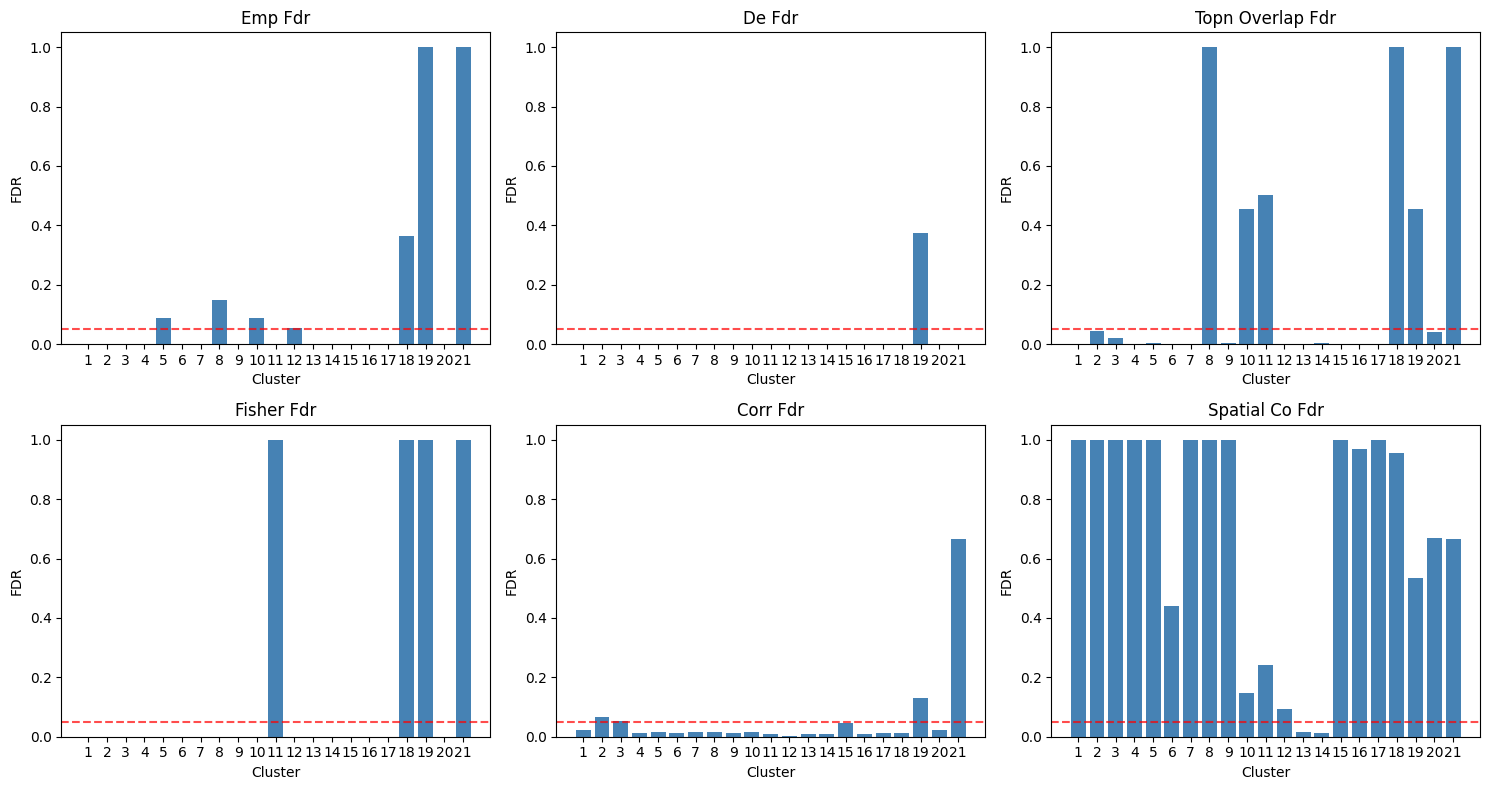

In [42]:

summary_df = adata.uns['cell_subtype_prediction_summary'].copy()
summary_df['cluster'] = summary_df['cluster'].astype(str)

# 所有 FDR 欄位對照 method_switch
active_fdr_cols = [
    m
    for m in method_switch
    if method_switch.get(m, False) and (m in core_methods_all)
]

print("Active FDR methods:", active_fdr_cols)

if len(active_fdr_cols) == 0:
    print("No active methods to plot")
else:
    # -----------------------------
    # Use SAME cluster order as before
    # -----------------------------
    if 'clusters_sorted' in globals():
        clusters = [c for c in clusters_sorted
                    if c in summary_df['cluster'].values]
    else:
        # fallback: numeric order
        clusters = sorted(summary_df['cluster'].unique(), key=int)

    fig_cols = 3
    n_methods = len(active_fdr_cols)
    fig_rows = math.ceil(n_methods / fig_cols)

    fig, axes = plt.subplots(
        fig_rows, fig_cols,
        figsize=(5 * fig_cols, 4 * fig_rows)
    )

    if fig_rows * fig_cols > 1:
        axes = axes.flatten()
    else:
        axes = [axes]

    x_pos = np.arange(len(clusters))

    for i, col in enumerate(active_fdr_cols):
        ax = axes[i]

        # values in the same cluster order
        vals = [
            summary_df.loc[summary_df['cluster'] == c, col].mean()
            for c in clusters
        ]

        ax.bar(x_pos, vals, color='steelblue')
        ax.set_title(col.replace('_', ' ').title())
        ax.set_xlabel('Cluster')
        ax.set_ylabel('FDR')
        ax.axhline(0.05, color='red', linestyle='--', alpha=0.7)
        ax.set_ylim(0.0, 1.05)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(clusters, rotation=0)

    # 隱藏多餘的 subplot
    for j in range(len(active_fdr_cols), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


### Weighted ensemble rank and marker coverage across clusters

This panel summarizes how confidently KurtoRank assigns cell subtypes to each cluster and how well the underlying marker sets are represented. The left plot shows the weighted rank sum for every cluster, where lower scores indicate that the chosen subtype consistently ranks near the top across multiple FDR-based methods (strong ensemble agreement), while higher scores reflect weaker or more divergent support. The right plot displays marker coverage, defined as the fraction of predefined marker genes for the assigned subtype that appear among the cluster’s top differentially expressed genes. Together, these plots highlight clusters with both robust multi-method support and good marker recovery, and flag clusters where the assignment may be less reliable or driven by incomplete marker evidence.


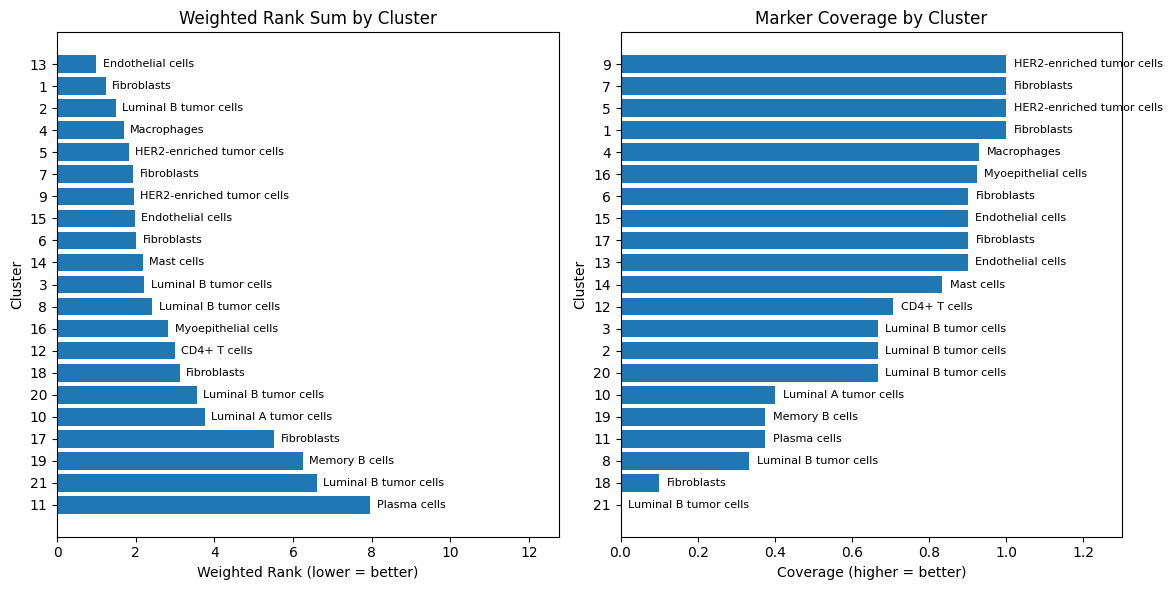

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Make sure clusters and subtype names are arrays of strings
clusters = summary_df['cluster'].astype(str).values
subtypes = summary_df['assigned_cell_subtype'].astype(str).values

# ---------------------------
# Left: Weighted rank sum
# ---------------------------
wrs_values = summary_df['weighted_rank_sum'].values.astype(float)

# sort: smaller rank → better → put on top
order_wrs = np.argsort(-wrs_values)          # ascending
wrs_sorted = wrs_values[order_wrs]
clusters_wrs = clusters[order_wrs]
subtypes_wrs = subtypes[order_wrs]

ax1 = axes[0]
ax1.barh(clusters_wrs, wrs_sorted)
ax1.set_title('Weighted Rank Sum by Cluster')
ax1.set_xlabel('Weighted Rank (lower = better)')
ax1.set_ylabel('Cluster')

# leave some room on the right so text is not cut off
xmax_wrs = wrs_sorted.max() * 1.6
ax1.set_xlim(0, xmax_wrs)

# add subtype labels to the right of each bar
x_pad = wrs_sorted.max() * 0.02  # small offset
for y, v, st in zip(clusters_wrs, wrs_sorted, subtypes_wrs):
    ax1.text(v + x_pad, y, st, va='center', ha='left', fontsize=8)

# ---------------------------
# Right: Marker coverage
# ---------------------------
mc_values = summary_df['marker_coverage'].values.astype(float)

# sort: higher coverage → better → put on top
order_mc = np.argsort(mc_values)           # descending
mc_sorted = mc_values[order_mc]
clusters_mc = clusters[order_mc]
subtypes_mc = subtypes[order_mc]

ax2 = axes[1]
ax2.barh(clusters_mc, mc_sorted)
ax2.set_title('Marker Coverage by Cluster')
ax2.set_xlabel('Coverage (higher = better)')
ax2.set_ylabel('Cluster')

xmax_mc = mc_sorted.max() * 1.3
ax2.set_xlim(0, xmax_mc)

x_pad2 = mc_sorted.max() * 0.02
for y, v, st in zip(clusters_mc, mc_sorted, subtypes_mc):
    ax2.text(v + x_pad2, y, st, va='center', ha='left', fontsize=8)

plt.tight_layout()
plt.show()


### Consensus scores and method-specific contributions across clusters

This panel summarizes how strongly the different statistical methods collectively support the final cell-type assignment for each cluster. The left plot compares unweighted and weighted consensus scores across clusters: the unweighted score reflects agreement when all active methods are treated equally, whereas the weighted score incorporates data-driven method weights (based on kurtosis of FDR distributions), giving more influence to methods that show sharper discrimination. Higher values indicate both low FDR and good agreement among methods. The right stacked bar plot decomposes the weighted consensus for each cluster into contributions from individual methods, showing which FDR metrics (e.g. empirical, DE-combined, Fisher enrichment, correlation, spatial co-localisation) dominate the final decision in each cluster. Together, these plots allow you to see where the ensemble is robust and which methods are driving the consensus.


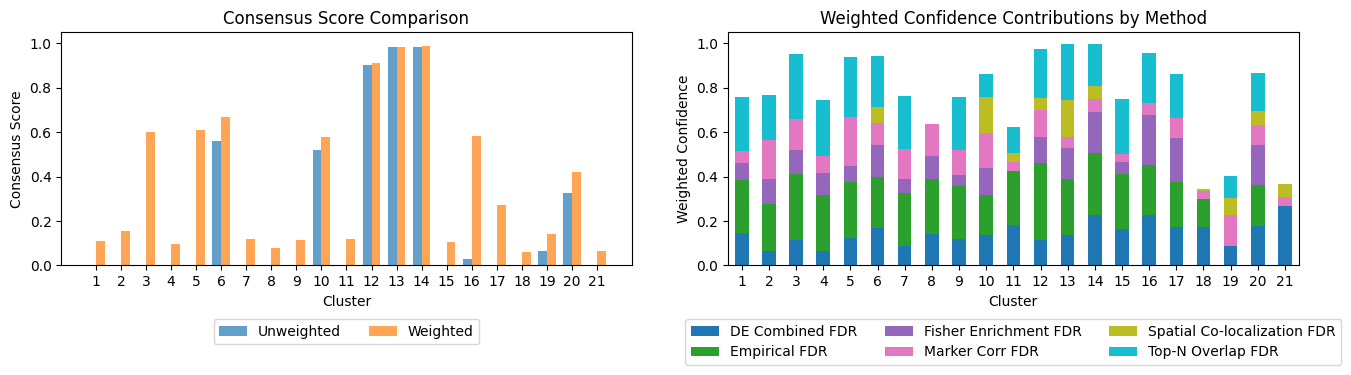

In [44]:

def calculate_unweighted_confidence(df, fdr_cols):
    fdr_matrix = df[fdr_cols].to_numpy(dtype=float)
    med = np.median(fdr_matrix, axis=1)
    abs_conf = 1.0 - np.clip(med, 0.0, 1.0)

    ranges = fdr_matrix.max(axis=1) - fdr_matrix.min(axis=1)
    max_range = ranges.max() if ranges.max() > 0 else 1.0
    agr_conf = 1.0 - (ranges / max_range)
    overall = np.clip(abs_conf * agr_conf, 0.0, 1.0)
    return overall


def calculate_weighted_confidence(df, fdr_cols):
    scores = []
    for _, row in df.iterrows():
        fdr_vals = np.array([row[c] for c in fdr_cols], dtype=float)
        weights = []
        for c in fdr_cols:
            w_col = c + '_weight'
            weights.append(row[w_col] if w_col in df.columns else 0.0)
        weights = np.array(weights, dtype=float)
        if np.all(weights == 0):
            weights = np.ones_like(weights)
        weights = weights / weights.sum()

        mean_fdr = float(np.sum(fdr_vals * weights))
        abs_conf = 1.0 - np.clip(mean_fdr, 0.0, 1.0)

        var = float(np.sum(weights * (fdr_vals - mean_fdr) ** 2))
        std = np.sqrt(var)
        std_upper = 0.5
        std_clipped = min(std, std_upper)
        agr_conf = 1.0 - (std_clipped / std_upper)

        overall = max(0.0, min(1.0, abs_conf * agr_conf))
        scores.append(overall)
    return np.array(scores)


if len(active_fdr_cols) > 0:
    # ------------------------------------------------------------------
    # 1) Prepare DF and canonical cluster order (same as agreement map)
    # ------------------------------------------------------------------
    summary_df_viz = summary_df.copy()
    summary_df_viz['cluster'] = summary_df_viz['cluster'].astype(str)

    if 'clusters_sorted' in globals():
        cluster_order = [c for c in clusters_sorted
                         if c in summary_df_viz['cluster'].values]
    else:
        # fallback: numeric sort
        cluster_order = sorted(summary_df_viz['cluster'].unique(), key=int)

    # reorder DF by cluster_order
    summary_df_viz = (
        summary_df_viz
        .set_index('cluster')
        .loc[cluster_order]
        .reset_index()
    )

    # convenience variable
    clusters = cluster_order

    # ------------------------------------------------------------------
    # 2) Compute unweighted & weighted confidence in this order
    # ------------------------------------------------------------------
    summary_df_viz['unweighted_confidence'] = calculate_unweighted_confidence(
        summary_df_viz, active_fdr_cols
    )
    summary_df_viz['weighted_confidence'] = calculate_weighted_confidence(
        summary_df_viz, active_fdr_cols
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # ------------------------------------------------------------------
    # 左：unweighted vs weighted (bar side-by-side, ordered by clusters)
    # ------------------------------------------------------------------
    x_pos = np.arange(len(clusters))
    width = 0.35

    axes[0].bar(
        x_pos - width / 2,
        summary_df_viz['unweighted_confidence'],
        width,
        label='Unweighted',
        alpha=0.7
    )
    axes[0].bar(
        x_pos + width / 2,
        summary_df_viz['weighted_confidence'],
        width,
        label='Weighted',
        alpha=0.7
    )
    axes[0].set_title('Consensus Score Comparison')
    axes[0].set_xlabel('Cluster')
    axes[0].set_ylabel('Consensus Score')
    axes[0].set_xticks(x_pos, clusters, rotation=0)
    axes[0].set_ylim(0.0, 1.05)
    axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)

    # ------------------------------------------------------------------
    # 右：方法貢獻堆疊圖 (stacked bar, same cluster order)
    # ------------------------------------------------------------------
    perf = pd.DataFrame({'cluster': clusters})
    for m in active_fdr_cols:
        conf = 1.0 - summary_df_viz[m].values.astype(float)
        w_col = m + '_weight'
        if w_col in summary_df_viz.columns:
            w = summary_df_viz[w_col].values.astype(float)
        else:
            w = np.zeros_like(conf)
        perf[method_labels[m]] = conf * w

    perf_melt = perf.melt(
        id_vars='cluster',
        var_name='method',
        value_name='weighted_confidence'
    )
    pivot = perf_melt.pivot(
        index='cluster',
        columns='method',
        values='weighted_confidence'
    )

    # ensure row order matches cluster_order
    pivot = pivot.loc[clusters]

    pivot.plot(
        kind='bar',
        stacked=True,
        ax=axes[1],
        colormap='tab10'
    )
    axes[1].set_title('Weighted Confidence Contributions by Method')
    axes[1].set_xlabel('Cluster')
    axes[1].set_ylabel('Weighted Confidence')
    axes[1].set_xticklabels(clusters, rotation=0)
    axes[1].set_ylim(0.0, 1.05)
    axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)

    plt.tight_layout()
    plt.show()


### FDR Heatmap Across Active Methods

This panel visualizes the distribution of false discovery rates (FDRs) for each active annotation method across all clusters. The heatmap provides a direct comparison of how stringent or permissive each method is in identifying the ensemble-selected subtype. Lower FDR values (lighter colors) indicate stronger statistical support, while higher values (darker colors) signify weaker confidence. By aligning clusters against all enabled methods, this plot highlights patterns of agreement, method-specific behavior, and clusters that are consistently well-supported versus those that remain challenging. This overview serves as a diagnostic map for identifying robust clusters, evaluating method reliability, and understanding where annotation uncertainty is concentrated.


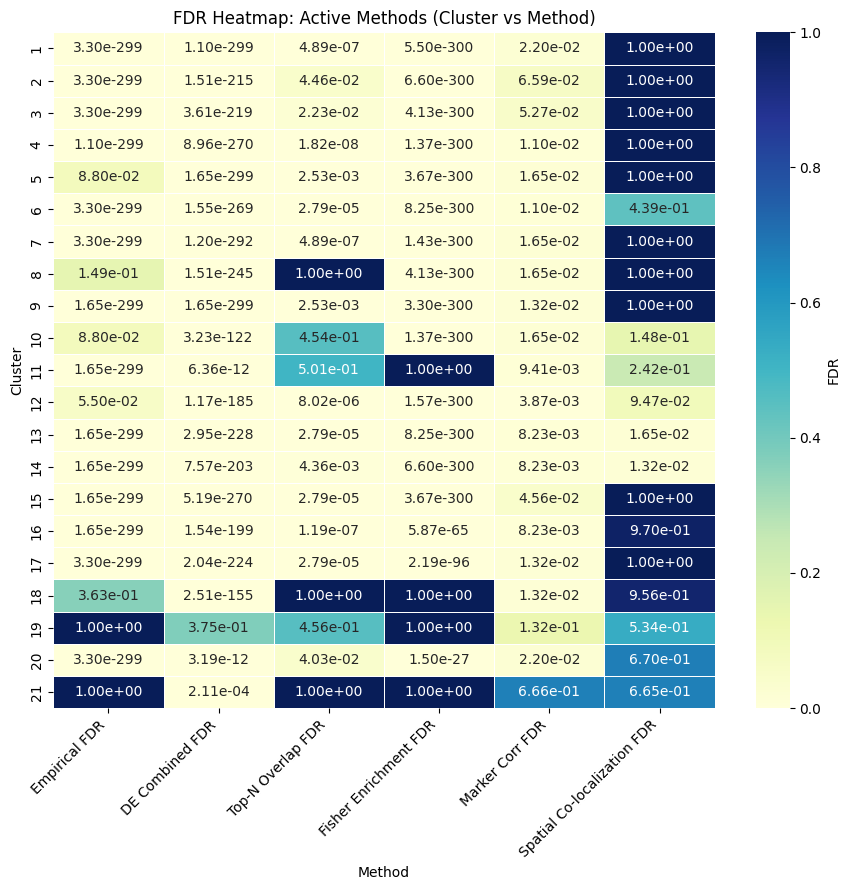


ANNOTATION SUMMARY STATISTICS

Number of clusters annotated: 21
Cell types identified: 11

Method Performance (active methods only):

                        Method  Mean_FDR  Median_FDR  Min_FDR  \
0                Empirical FDR    0.1306      0.0000   0.0000   
1              DE Combined FDR    0.0179      0.0000   0.0000   
2            Top-N Overlap FDR    0.2156      0.0025   0.0000   
3        Fisher Enrichment FDR    0.1905      0.0000   0.0000   
4              Marker Corr FDR    0.0558      0.0165   0.0039   
5  Spatial Co-localization FDR    0.7023      0.9701   0.0132   

   Significant_Clusters (FDR<0.05)  
0                               14  
1                               20  
2                               15  
3                               17  
4                               17  
5                                2  

Clusters with tied assignments: 0


In [45]:

if len(active_fdr_cols) > 0:
    # Make sure cluster is string
    summary_df_ord = summary_df.copy()
    summary_df_ord['cluster'] = summary_df_ord['cluster'].astype(str)

    # Use SAME cluster order as the agreement heatmap
    if 'clusters_sorted' in globals():
        cluster_order = [c for c in clusters_sorted
                         if c in summary_df_ord['cluster'].values]
    else:
        # fallback: numeric order
        cluster_order = sorted(summary_df_ord['cluster'].unique(), key=int)

    plt.figure(figsize=(9, 9))

    # Reindex by cluster_order, then select active FDR cols
    heatmap_data = (
        summary_df_ord
        .set_index('cluster')
        .loc[cluster_order, active_fdr_cols]
        .astype(float)
    )
    heatmap_data.columns = [method_labels[c] for c in heatmap_data.columns]

    ax = sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.2e',
        cmap='YlGnBu',
        cbar_kws={'label': 'FDR'},
        linewidths=0.5
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.title('FDR Heatmap: Active Methods (Cluster vs Method)')
    plt.ylabel('Cluster')
    plt.xlabel('Method')
    plt.tight_layout()
    plt.show()

    # summary
    print("\n" + "="*60)
    print("ANNOTATION SUMMARY STATISTICS")
    print("="*60)
    print(f"\nNumber of clusters annotated: {len(summary_df_ord)}")
    print(f"Cell types identified: {summary_df_ord['assigned_cell_subtype'].nunique()}\n")

    method_performance = pd.DataFrame({
        'Method': [method_labels[m] for m in active_fdr_cols],
        'Mean_FDR':   [summary_df_ord[m].mean()   for m in active_fdr_cols],
        'Median_FDR': [summary_df_ord[m].median() for m in active_fdr_cols],
        'Min_FDR':    [summary_df_ord[m].min()    for m in active_fdr_cols],
        'Significant_Clusters (FDR<0.05)': [
            int((summary_df_ord[m] < 0.05).sum()) for m in active_fdr_cols
        ]
    })
    print("Method Performance (active methods only):\n")
    print(method_performance.round(4))

    if 'other_tied_cell_subtypes' in summary_df_ord.columns:
        tied_assignments = (summary_df_ord['other_tied_cell_subtypes'] != '').sum()
        print(f"\nClusters with tied assignments: {tied_assignments}")


### Cross-method correlation of FDR profiles across clusters

Interpretation (professional English):
This heatmap summarizes how similarly each active annotation method behaves across all clusters by computing pairwise Spearman correlations of their FDR values. Each cell represents the correlation between a pair of methods, with warm colors (values close to 1) indicating that two methods tend to assign low/high FDRs to the same clusters (i.e., they are largely redundant), and cool colors (values near 0 or negative) suggesting that they capture partially independent or even opposing signals. Strongly correlated blocks highlight families of methods that effectively measure the same underlying evidence, whereas lower correlations point to complementary methods that may add unique information to the KurtoRank ensemble. This panel therefore provides a compact view of redundancy versus diversity among the active FDR-based scoring schemes.


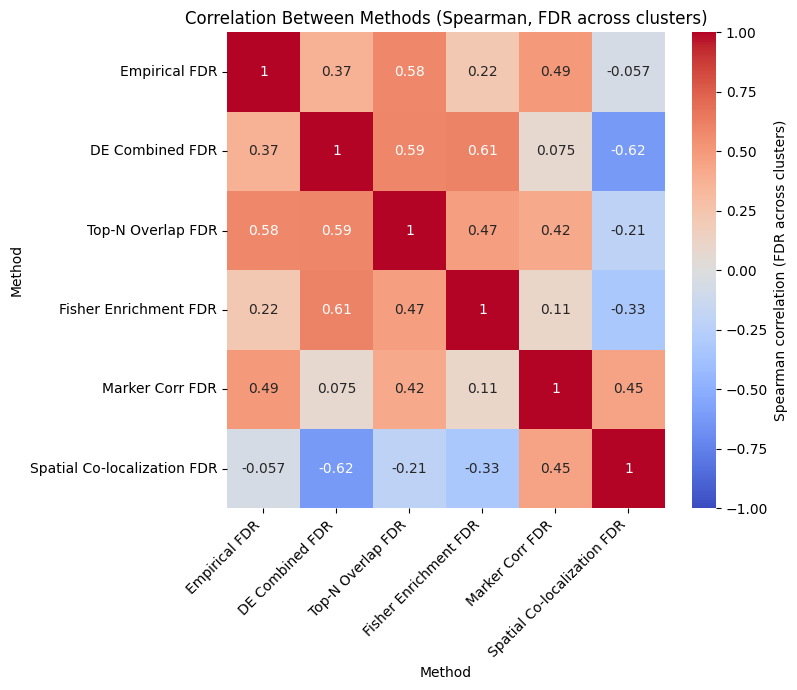

In [46]:
if len(active_fdr_cols) > 1:
    corr_mat = np.zeros((len(active_fdr_cols), len(active_fdr_cols)))
    for i, m1 in enumerate(active_fdr_cols):
        for j, m2 in enumerate(active_fdr_cols):
            x = summary_df[m1].values.astype(float)
            y = summary_df[m2].values.astype(float)
            rho, _ = spearmanr(x, y)
            corr_mat[i, j] = rho

    plt.figure(figsize=(8, 7))
    corr_df = pd.DataFrame(
        corr_mat,
        index=[method_labels[m] for m in active_fdr_cols],
        columns=[method_labels[m] for m in active_fdr_cols]
    )
    ax = sns.heatmap(
        corr_df,
        annot=True,
        vmin=-1, vmax=1,
        cmap='coolwarm',
        cbar_kws={'label': 'Spearman correlation (FDR across clusters)'}
    )
    plt.title('Correlation Between Methods (Spearman, FDR across clusters)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.ylabel('Method')
    plt.xlabel('Method')
    plt.tight_layout()
    plt.show()

### Cross-Method Agreement and Support for Ensemble Cell-Type Assignment

Panel A — Method-Level Agreement with the KurtoRank Ensemble: This bar plot summarizes how often each individual annotation method agrees with the KurtoRank ensemble in selecting the same cell subtype across clusters. An agreement is counted when a method’s lowest-FDR subtype matches the ensemble’s final choice for that cluster. Higher agreement rates indicate that a method consistently converges toward the ensemble’s decision, reflecting robustness, stability, or shared statistical signal. Conversely, lower agreement highlights divergence in the evidence captured by that method.

Panel B — Cluster-Level Agreement Matrix (Method vs Ensemble): The heatmap presents, for every cluster and every method, whether the chosen subtype matches the ensemble (1 = agree, 0 = disagree). This provides a high-resolution view of concordance patterns: horizontal patterns indicate clusters that are universally easy or difficult for methods to annotate; vertical patterns reveal methods that either align consistently with the ensemble or deviate frequently. This matrix helps identify method families that behave similarly, as well as clusters that require deeper examination due to cross-method disagreement.

Panel C — Strength of Support for the Ensemble Assignment: The histogram quantifies, for each cluster, how many active methods produce strong evidence for the ensemble-assigned subtype (defined as FDR < 0.05). A high support count implies a well-validated annotation with consistent multi-method evidence, while low counts suggest ambiguous or weakly supported assignments that deserve cautious interpretation. This distribution serves as a diagnostic summary of annotation confidence across the dataset.


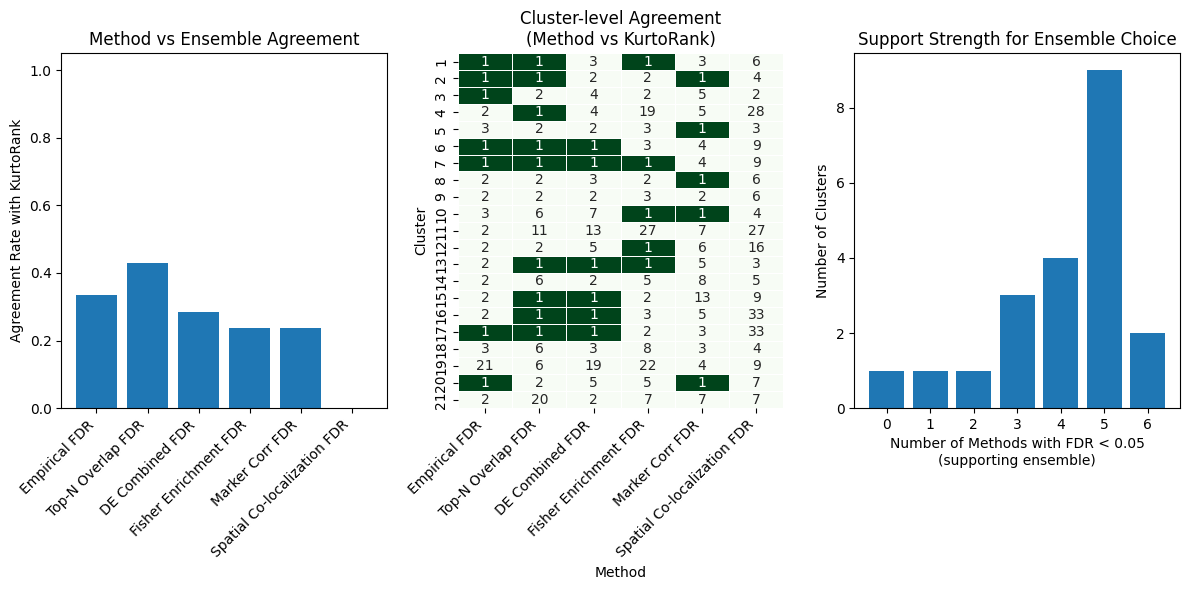

In [47]:

# === 6.8 + 6.9 Combined: 3-Panel Summary Figure (Revised) ===

enabled_methods = [
    m for m in core_methods_all
    if method_switch.get(m, True) and m in summary_df.columns
]

if len(enabled_methods) == 0:
    print("No enabled methods for agreement/support analysis.")

else:
    # ------------------------------------------------------------
    # Prepare cluster order + ensemble subtype mapping
    # ------------------------------------------------------------
    summary_df_ag = summary_df.copy()
    summary_df_ag['cluster'] = summary_df_ag['cluster'].astype(str)
    ensemble_map = summary_df_ag.set_index('cluster')['assigned_cell_subtype'].to_dict()
    clusters_sorted = sorted(ensemble_map.keys(), key=int)

    # ============================================================
    # (A) Build 2 matrices:
    #     - agree_matrix: 0/1 (method's best guess == ensemble)
    #     - rank_matrix: ranking of ensemble subtype in each method
    # ============================================================
    agree_matrix = pd.DataFrame(index=clusters_sorted, columns=enabled_methods, dtype=float)
    rank_matrix  = pd.DataFrame(index=clusters_sorted, columns=enabled_methods, dtype=float)

    for m in enabled_methods:
        # Candidate subtypes for this method
        sub = final_df[['cluster', 'cell_subtype', m]].copy()
        sub['cluster'] = sub['cluster'].astype(str)
        sub = sub[sub['cluster'].isin(clusters_sorted)]

        # Compute agreement + rank per cluster using the SAME ordering
        for cl in clusters_sorted:
            ens_ct = ensemble_map[cl]  # Ensemble (KurtoRank) subtype

            sub_cl = sub[sub['cluster'] == cl].copy()
            if sub_cl.empty:
                agree_matrix.loc[cl, m] = np.nan
                rank_matrix.loc[cl, m] = np.nan
                continue

            # Stable sort by FDR/score ascending; first = best guess
            sub_cl = sub_cl.sort_values(by=m, ascending=True, kind='mergesort')
            ordered_subtypes = list(sub_cl['cell_subtype'])

            method_best = ordered_subtypes[0]
            agree_matrix.loc[cl, m] = 1.0 if method_best == ens_ct else 0.0

            if ens_ct in ordered_subtypes:
                rank_matrix.loc[cl, m] = ordered_subtypes.index(ens_ct) + 1  # 1-based rank
            else:
                rank_matrix.loc[cl, m] = np.nan

    # Method-level agreement rate (mean of 0/1 per method)
    method_agree_rate = agree_matrix.mean(axis=0)

    # Rename columns for plotting
    agree_hm = agree_matrix.copy()
    agree_hm.columns = [method_labels[m] for m in enabled_methods]

    rank_hm = rank_matrix.copy()
    rank_hm.columns = [method_labels[m] for m in enabled_methods]

    # ============================================================
    # (B) Strong supporter count (# methods with FDR < 0.05)
    # ============================================================
    summary_df_sc = summary_df.copy()
    summary_df_sc['cluster'] = summary_df_sc['cluster'].astype(str)

    rows = []
    for _, row in summary_df_sc.iterrows():
        cl = str(row['cluster'])
        ct = row['assigned_cell_subtype']
        hit = final_df[
            (final_df['cluster'].astype(str) == cl) &
            (final_df['cell_subtype'] == ct)
        ]
        if not hit.empty:
            rows.append(hit.iloc[0])

    chosen_df = pd.DataFrame(rows).reset_index(drop=True)
    chosen_df['cluster'] = chosen_df['cluster'].astype(str)

    support_counts = []
    for _, r in chosen_df.iterrows():
        vals = [r[m] for m in enabled_methods]
        support_counts.append(sum(np.array(vals) < 0.05))

    chosen_df['n_support_methods'] = support_counts

    summary_df['n_support_methods'] = chosen_df.set_index('cluster')[
        'n_support_methods'
    ].reindex(summary_df['cluster'].astype(str)).values

    # ============================================================
    # (C) ---- PLOT ALL THREE PANELS ----
    # ============================================================
    fig, axes = plt.subplots(1, 3, figsize=(12, 6))

    # ------------------------------------------------------------
    # Plot 1: Barplot of method agreement rate
    # ------------------------------------------------------------
    ax = axes[0]
    x_labels = [method_labels[m] for m in enabled_methods]
    ax.bar(range(len(enabled_methods)), method_agree_rate.values)
    ax.set_xticks(range(len(enabled_methods)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_ylabel("Agreement Rate with KurtoRank")
    ax.set_ylim(0, 1.05)
    ax.set_title("Method vs Ensemble Agreement")

    # ------------------------------------------------------------
    # Plot 2: Modified Heatmap
    #   - Color: 0/1 (green only for agreement)
    #   - Annotation: rank of ensemble subtype (1 = identical)
    # ------------------------------------------------------------
    ax = axes[1]

    sns.heatmap(
        agree_hm,               # 0/1 for color
        annot=rank_hm,          # rank values for annotation
        fmt=".0f",
        cmap="Greens",
        cbar=False,
        # cbar_kws={'label': 'Agreement (1=yes, 0=no)'},
        linewidths=0.5,
        ax=ax
    )

    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_title("Cluster-level Agreement\n(Method vs KurtoRank)")
    ax.set_ylabel("Cluster")
    ax.set_xlabel("Method")

    # ------------------------------------------------------------
    # Plot 3: Support Count Histogram
    # ------------------------------------------------------------
    ax = axes[2]
    ax.hist(
        support_counts,
        bins=range(0, len(enabled_methods) + 2),
        align='left',
        rwidth=0.8
    )
    ax.set_xlabel("Number of Methods with FDR < 0.05\n(supporting ensemble)")
    ax.set_ylabel("Number of Clusters")
    ax.set_title("Support Strength for Ensemble Choice")
    ax.set_xticks(range(0, len(enabled_methods) + 1))

    plt.tight_layout()
    plt.show()


### Method entropy and its relationship to ensemble confidence

This panel summarizes how much each cluster’s final annotation relies on a few dominant methods versus a broad mix of methods, and how that relates to the overall ensemble confidence. The left plot shows the normalized method entropy for each cluster: values close to 0 indicate that one or two FDR methods carry most of the weight in the KurtoRank ensemble (strongly dominated decision), whereas values closer to 1 mean that many methods contribute more evenly to the final call. The right plot compares this entropy to the weighted consensus score for each cluster. Points in the upper-left region correspond to clusters where a small number of methods strongly agree and the ensemble is very confident, while points in the upper-right suggest high confidence supported by many methods simultaneously. Conversely, low-confidence clusters (lower part of the plot) highlight cases where either the methods disagree or none of them provide a very strong signal, helping you identify annotations that may require manual review or additional data.


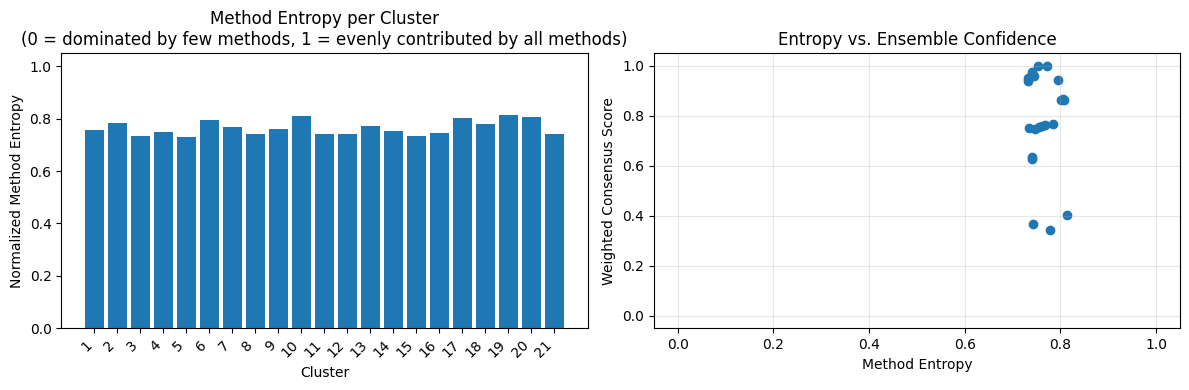

In [48]:

# --- 6.9 / 6.10 preparation: compute weighted_confidence first ----------------
core_methods_all = enabled_methods = [
    m for m in core_methods_all
    if method_switch.get(m, True) and m in summary_df.columns
]

# keep only methods that are present and actually used (weight > 0 somewhere)
active_fdr_cols = []
for m in core_methods_all:
    if m in summary_df.columns:
        w_col = m + '_weight'
        if (w_col in summary_df.columns) and (summary_df[w_col].sum() > 0):
            active_fdr_cols.append(m)

if len(active_fdr_cols) == 0:
    print("No active methods found for weighted_confidence.")
else:
    weighted_confidence = []

    for _, row in summary_df.iterrows():
        fdr_vals = np.array([row[m] for m in active_fdr_cols], dtype=float)

        # matching weights
        w = np.array([row[m + '_weight'] for m in active_fdr_cols], dtype=float)
        if np.all(w == 0):
            w = np.ones_like(w)
        w = w / w.sum()

        # smaller weighted mean FDR → higher confidence
        mean_fdr = float(np.sum(fdr_vals * w))
        conf = 1.0 - np.clip(mean_fdr, 0.0, 1.0)   # map to [0, 1]
        weighted_confidence.append(conf)

    summary_df['weighted_confidence'] = weighted_confidence


# === 6.10 Method Entropy: 每個 cluster 的「資訊集中度」 ==========================
summary_df_ent = summary_df.copy()
summary_df_ent['cluster'] = summary_df_ent['cluster'].astype(str)

# compute normalized entropy per cluster based on method weights
method_weight_cols = [c for c in summary_df_ent.columns if c.endswith('_weight')]
weight_matrix = summary_df_ent[method_weight_cols].to_numpy(dtype=float)

entropies = []
for row in weight_matrix:
    w = row.copy()
    if w.sum() <= 0:
        entropies.append(0.0)
        continue
    w = w / w.sum()
    # Shannon entropy
    H = -np.sum([p * np.log2(p) for p in w if p > 0])
    # normalize by max possible entropy = log2(#methods)
    H_max = np.log2(len(w))
    entropies.append(float(H / H_max if H_max > 0 else 0.0))

summary_df_ent['method_entropy'] = entropies


# --- Plot: entropy bar + entropy vs confidence in the SAME ROW ---------------

# Use the SAME cluster order as the agreement heatmap
if 'clusters_sorted' in globals():
    cluster_order = [c for c in clusters_sorted
                     if c in summary_df_ent['cluster'].values]
else:
    # fallback: numeric sort
    cluster_order = sorted(summary_df_ent['cluster'].unique(), key=int)

# re-order the DF for plotting
summary_df_ent_ord = (
    summary_df_ent
    .set_index('cluster')
    .loc[cluster_order]
    .reset_index()
)

clusters_str = summary_df_ent_ord['cluster']

if 'weighted_confidence' in summary_df_ent_ord.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: entropy per cluster (ordered)
    axes[0].bar(range(len(cluster_order)), summary_df_ent_ord['method_entropy'])
    axes[0].set_xticks(range(len(cluster_order)))
    axes[0].set_xticklabels(cluster_order, rotation=45, ha='right')
    axes[0].set_xlabel('Cluster')
    axes[0].set_ylabel('Normalized Method Entropy')
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title(
        'Method Entropy per Cluster\n'
        '(0 = dominated by few methods, 1 = evenly contributed by all methods)'
    )

    # Right: entropy vs weighted consensus confidence (order irrelevant here)
    axes[1].scatter(summary_df_ent_ord['method_entropy'],
                    summary_df_ent_ord['weighted_confidence'])
    axes[1].set_xlabel('Method Entropy')
    axes[1].set_ylabel('Weighted Consensus Score')
    axes[1].set_title('Entropy vs. Ensemble Confidence')
    axes[1].grid(alpha=0.3)
    axes[1].set_xlim(-0.05, 1.05)
    axes[1].set_ylim(-0.05, 1.05)

    plt.tight_layout()
    plt.show()

else:
    # fallback: only entropy barplot
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(range(len(cluster_order)), summary_df_ent_ord['method_entropy'])
    ax.set_xticks(range(len(cluster_order)))
    ax.set_xticklabels(cluster_order, rotation=45, ha='right')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Normalized Method Entropy')
    ax.set_ylim(0, 1.05)
    ax.set_title(
        'Method Entropy per Cluster\n'
        '(0 = dominated by few methods, 1 = evenly contributed by all methods)'
    )
    plt.tight_layout()
    plt.show()


### Visualize results

/tmp/ipykernel_2023803/2958468107.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


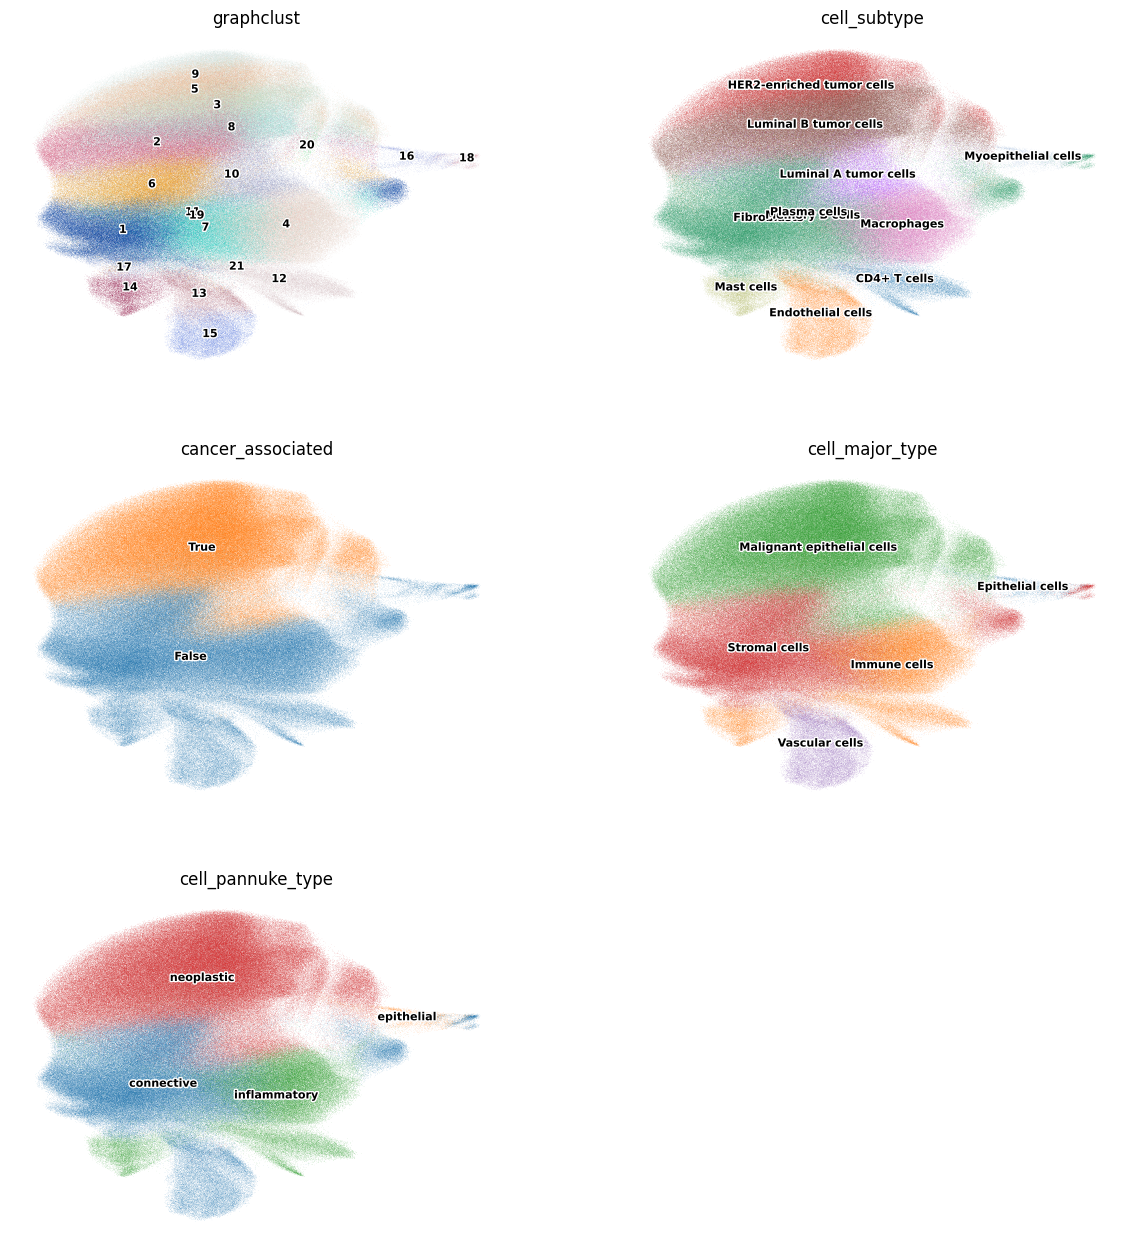

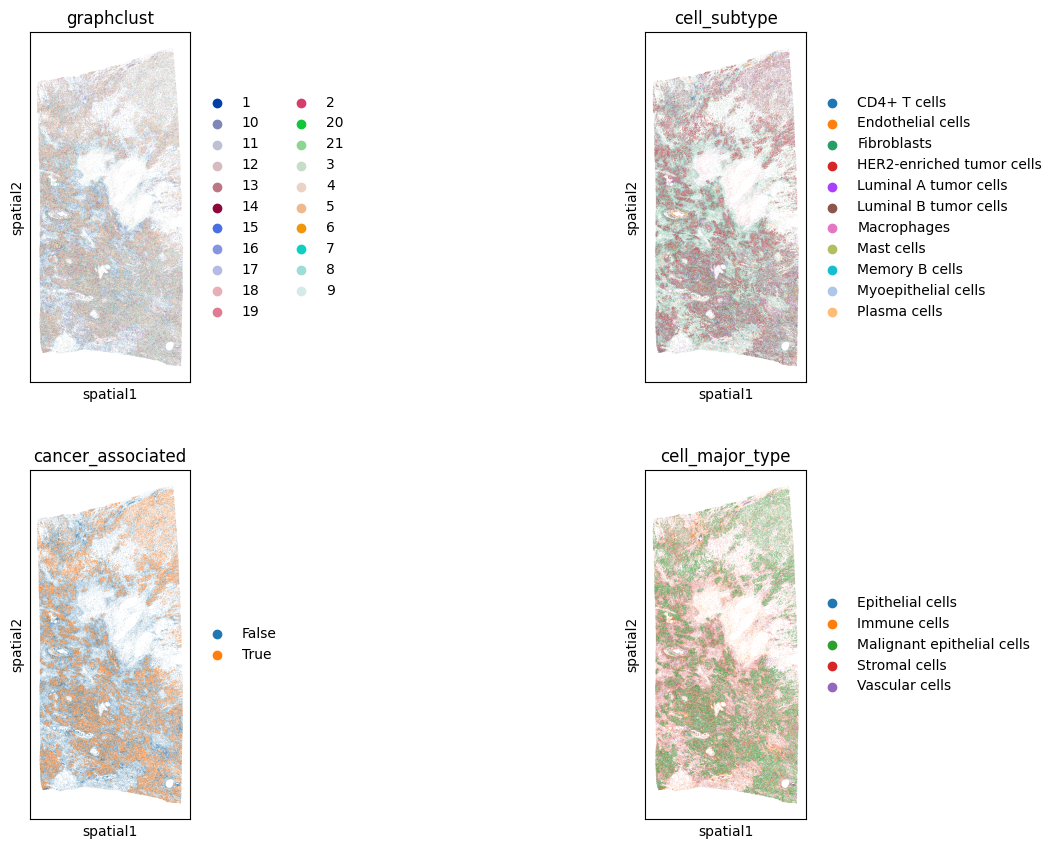

In [49]:
# 7.1 UMAP + Spatial 結果
sc.pl.umap(
    adata,
    color=[primary_cluster, 'cell_subtype', 'cancer_associated', 'cell_major_type', 'cell_pannuke_type'],
    show=False,
    ncols=2,
    title=[primary_cluster, 'cell_subtype', 'cancer_associated', 'cell_major_type', 'cell_pannuke_type'],
    legend_loc='on data',
    legend_fontsize=8,
    legend_fontoutline=2,
    frameon=False
)
sc.pl.spatial(
    adata,
    color=[primary_cluster, 'cell_subtype', 'cancer_associated', 'cell_major_type'],
    size=10,
    ncols=2,
    show=False,
    spot_size=1,
    title=[primary_cluster, 'cell_subtype', 'cancer_associated', 'cell_major_type']
)
plt.tight_layout()
plt.show()


### Additional visualizations. Get top marker genes for each cell type

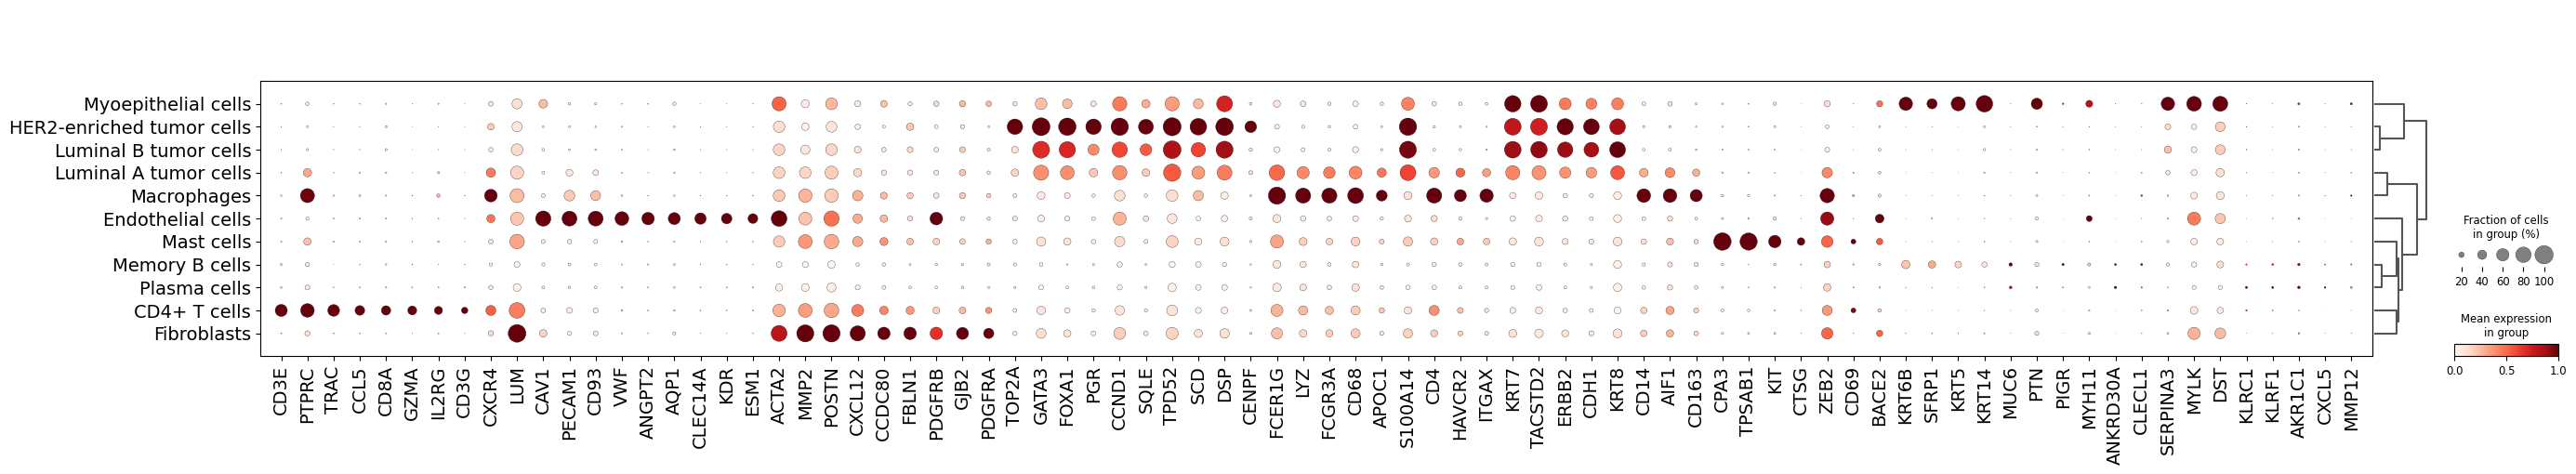

In [50]:
# 7.2 dotplot: 每個 cell_subtype 的 top markers
sc.tl.rank_genes_groups(
    adata,
    groupby='cell_subtype',
    method='wilcoxon',
    use_raw=False,
    key_added='dotplot',
)
top_markers = []
for group in adata.obs['cell_subtype'].cat.categories:
    markers = sc.get.rank_genes_groups_df(adata, group=group, key='dotplot').head(10)['names'].tolist()
    top_markers.extend(markers)
top_markers = list(dict.fromkeys(top_markers))

sc.tl.dendrogram(adata, groupby='cell_subtype')
fig = sc.pl.dotplot(adata,
                    var_names=top_markers,
                    groupby='cell_subtype',
                    standard_scale='var',
                    dendrogram=True,
                    return_fig=True)

axes_list = fig.get_axes()
ax = axes_list['mainplot_ax']
for label in ax.get_xticklabels():
    label.set_fontsize(14)
for label in ax.get_yticklabels():
    label.set_fontsize(14)


### Generate a report on cell type composition

/tmp/ipykernel_2023803/2618453833.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_2023803/2618453833.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_2023803/2618453833.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(axs[2].get_xticklabels(), rotation=45, ha='right')


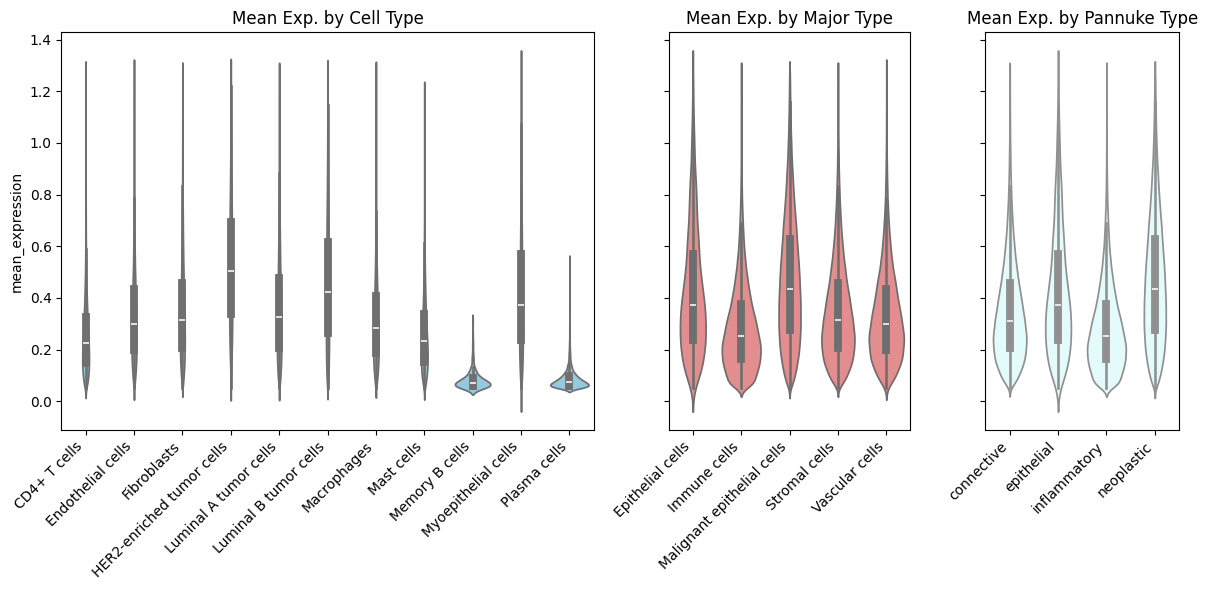

In [51]:
# 7.3 Violin plot: mean expression by subtype / major type
adata.obs["mean_expression"] = (adata.raw.X).toarray().mean(axis=1)

subtype_bars = len(adata.obs["cell_subtype"].unique())
majortype_bars = len(adata.obs["cell_major_type"].unique())
pannuketype_bars = len(adata.obs["cell_pannuke_type"].unique())

width_ratios = [subtype_bars, majortype_bars, pannuketype_bars]

fig, axs = plt.subplots(
    1, 3, figsize=(12, 6),
    gridspec_kw={'width_ratios': width_ratios},
    sharey=True
)
sns.violinplot(
    x=adata.obs["cell_subtype"],
    y=adata.obs["mean_expression"],
    color='skyblue',
    ax=axs[0]
)
axs[0].set_title("Mean Exp. by Cell Type")
# axs[0].tick_params(axis='x', rotation=90)
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45, ha='right')
axs[0].set_xlabel('')

sns.violinplot(
    x=adata.obs["cell_major_type"],
    y=adata.obs["mean_expression"],
    color='lightcoral',
    ax=axs[1]
)
axs[1].set_title("Mean Exp. by Major Type")
# axs[1].tick_params(axis='x', rotation=90)
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45, ha='right')
axs[1].set_xlabel('')

sns.violinplot(
    x=adata.obs["cell_pannuke_type"],
    y=adata.obs["mean_expression"],
    color='lightcyan',
    ax=axs[2]
)
axs[2].set_title("Mean Exp. by Pannuke Type")
# axs[2].tick_params(axis='x', rotation=90)
axs[2].set_xticklabels(axs[2].get_xticklabels(), rotation=45, ha='right')
axs[2].set_xlabel('')
plt.tight_layout()
plt.show()


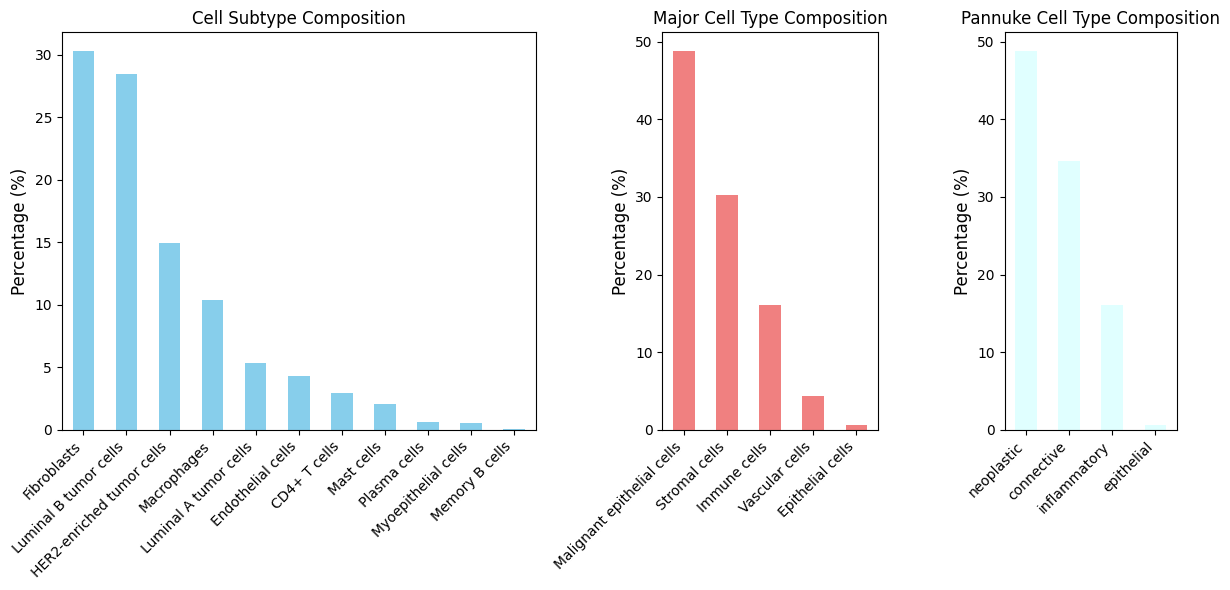

In [52]:
# 7.4 組成 bar plot（subtype / major type）
cell_counts = adata.obs['cell_subtype'].value_counts()
cell_percent = (cell_counts / len(adata)) * 100
composition_df = pd.DataFrame({
    'Count': cell_counts,
    'Percentage': cell_percent
})

cat_counts = adata.obs['cell_major_type'].value_counts()
cat_percent = (cat_counts / len(adata)) * 100
category_df = pd.DataFrame({
    'Count': cat_counts,
    'Percentage': cat_percent
})

pannuke_counts = adata.obs['cell_pannuke_type'].value_counts()
pannuke_percent = (pannuke_counts / len(adata)) * 100
pannuke_df = pd.DataFrame({
    'Count': pannuke_counts,
    'Percentage': pannuke_percent
})

subtype_bars = len(composition_df)
majortype_bars = len(category_df)
pannuke_bars = len(pannuke_df)

width_ratios = [subtype_bars, majortype_bars, pannuke_bars]

fig, axes = plt.subplots(
    1, 3, figsize=(12, 6),
    gridspec_kw={'width_ratios': width_ratios}
)
composition_df['Percentage'].plot(kind='bar', color='skyblue', ax=axes[0])
axes[0].set_title('Cell Subtype Composition', fontsize=12)
axes[0].set_ylabel('Percentage (%)', fontsize=12)
axes[0].set_xlabel('')
# axes[0].tick_params(axis='x', rotation=90, labelsize=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

category_df['Percentage'].plot(kind='bar', color='lightcoral', ax=axes[1])
axes[1].set_title('Major Cell Type Composition', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].set_xlabel('')
# axes[1].tick_params(axis='x', rotation=90, labelsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

pannuke_df['Percentage'].plot(kind='bar', color='lightcyan', ax=axes[2])
axes[2].set_title('Pannuke Cell Type Composition', fontsize=12)
axes[2].set_ylabel('Percentage (%)', fontsize=12)
axes[2].set_xlabel('')
# axes[2].tick_params(axis='x', rotation=90, labelsize=10)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


### Visualize the cell type assignment 

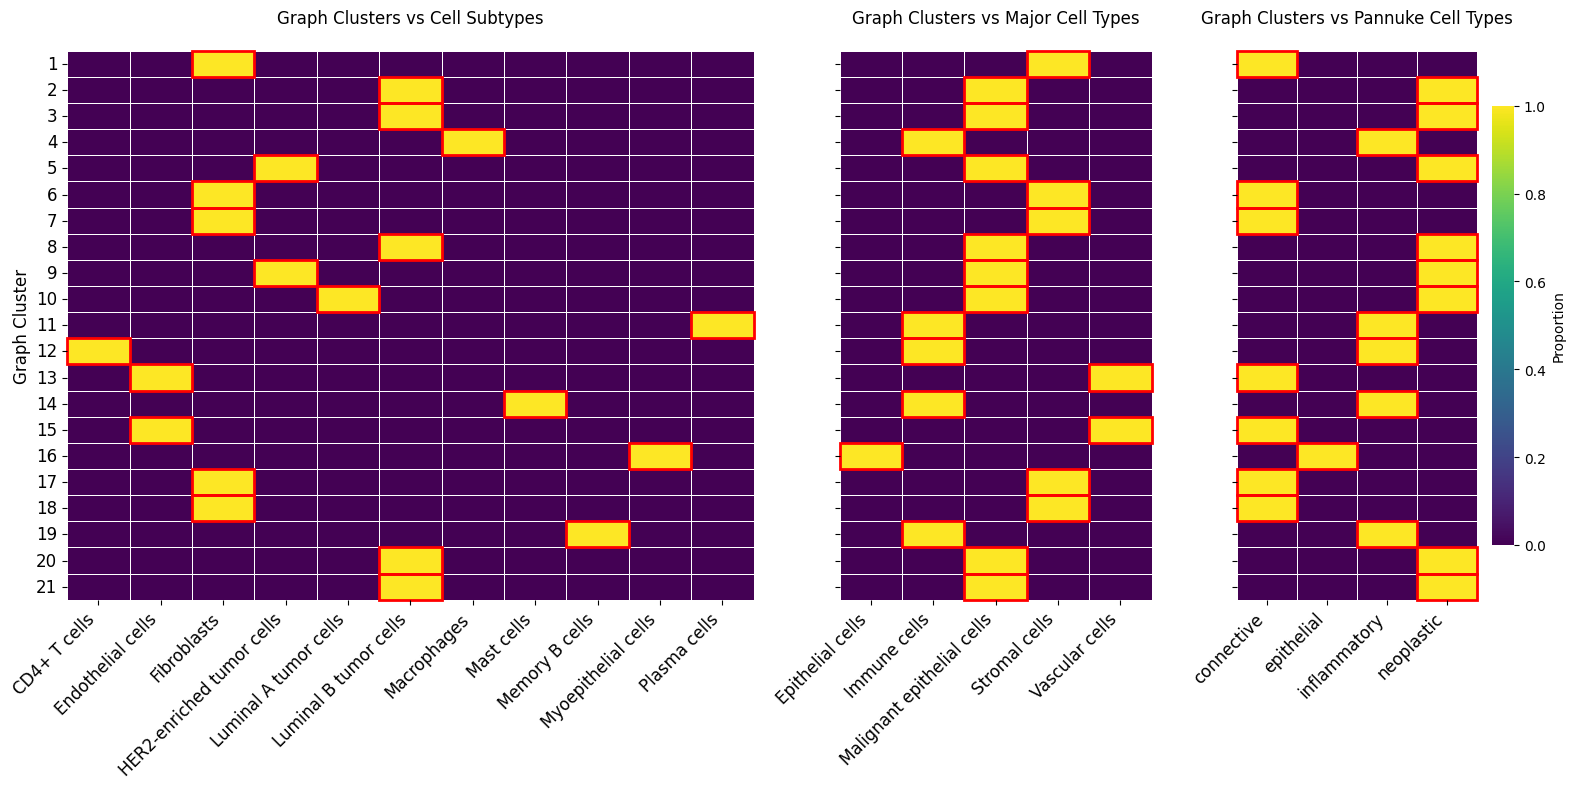

In [53]:
def create_heatmap_data(adata, cluster_col, celltype_col, significant_threshold=0.0):
    cluster_categories = adata.obs[cluster_col].unique()
    celltype_categories = adata.obs[celltype_col].unique()
    heatmap_data = pd.DataFrame(
        index=sorted(cluster_categories, key=int),
        columns=sorted(celltype_categories)
    )
    for cluster in cluster_categories:
        subset = adata[adata.obs[cluster_col] == cluster]
        norm_counts = subset.obs[celltype_col].value_counts(normalize=True)
        for celltype, value in norm_counts.items():
            heatmap_data.loc[cluster, celltype] = value
    heatmap_data = heatmap_data.fillna(0)
    columns_sums = heatmap_data.sum()
    significant_columns = columns_sums[columns_sums >= significant_threshold].index
    heatmap_data = heatmap_data[significant_columns]
    return heatmap_data

subtype_data = create_heatmap_data(adata, 'graphclust', 'cell_subtype')
majortype_data = create_heatmap_data(adata, 'graphclust', 'cell_major_type')
pannuketype_data = create_heatmap_data(adata, 'graphclust', 'cell_pannuke_type')

common_clusters = sorted(set(subtype_data.index) & set(majortype_data.index) & set(pannuketype_data.index), key=int)
subtype_data = subtype_data.loc[common_clusters]
majortype_data = majortype_data.loc[common_clusters]
pannuketype_data = pannuketype_data.loc[common_clusters]

global_min = min(subtype_data.min().min(), majortype_data.min().min())
global_max = max(subtype_data.max().max(), majortype_data.max().max())

subtype_cols = subtype_data.shape[1]
majortype_cols = majortype_data.shape[1]
pannuketype_cols = pannuketype_data.shape[1]

colorbar_compensation = 1.2
width_ratios = [subtype_cols, majortype_cols, pannuketype_cols * colorbar_compensation]

fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, figsize=(16, 8),
    gridspec_kw={'width_ratios': width_ratios}
)

sns.heatmap(
    subtype_data,
    annot=False,
    cmap='viridis',
    linewidths=0.5,
    ax=ax1,
    cbar=False,
    vmin=global_min,
    vmax=global_max
)
sns.heatmap(
    majortype_data,
    annot=False,
    cmap='viridis',
    linewidths=0.5,
    ax=ax2,
    cbar=False,
    cbar_kws={'label': 'Proportion', 'shrink': 0.8},
    vmin=global_min,
    vmax=global_max
)
sns.heatmap(
    pannuketype_data,
    annot=False,
    cmap='viridis',
    linewidths=0.5,
    ax=ax3,
    cbar=True,
    cbar_kws={'label': 'Proportion', 'shrink': 0.8},
    vmin=global_min,
    vmax=global_max
)
def add_highlights(ax, data, highlight_color='red', highlight_linewidth=2, highlight_threshold=0.0):
    for i, row_idx in enumerate(data.index):
        row_max = np.max(data.loc[row_idx].values)
        for j, col_idx in enumerate(data.columns):
            value = data.loc[row_idx, col_idx]
            if value == row_max and value > highlight_threshold:
                ax.add_patch(plt.Rectangle(
                    (j, i), 1, 1,
                    fill=False,
                    edgecolor=highlight_color,
                    lw=highlight_linewidth,
                    clip_on=False
                ))

add_highlights(ax1, subtype_data)
add_highlights(ax2, majortype_data)
add_highlights(ax3, pannuketype_data)

ax1.set_title('Graph Clusters vs Cell Subtypes', fontsize=12, pad=20)
ax1.set_ylabel('Graph Cluster', fontsize=12)
ax1.tick_params(axis='x', rotation=90, labelsize=12)
ax1.tick_params(axis='y', rotation=0, labelsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

ax2.set_title('Graph Clusters vs Major Cell Types', fontsize=12, pad=20)
ax2.set_ylabel('')
ax2.tick_params(axis='x', rotation=90, labelsize=12)
ax2.tick_params(axis='y', rotation=0, labelsize=12)
ax2.set_yticklabels([])
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

ax3.set_title('Graph Clusters vs Pannuke Cell Types', fontsize=12, pad=20)
ax3.set_ylabel('')
ax3.tick_params(axis='x', rotation=90, labelsize=12)
ax3.tick_params(axis='y', rotation=0, labelsize=12)
ax3.set_yticklabels([])
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [54]:
cell_subtype_assignment = pd.DataFrame({
    'classification': subtype_data.idxmax(axis=1).index.tolist(),
    'cell_subtype': subtype_data.idxmax(axis=1).tolist(),
}).set_index('classification')
cell_subtype_assignment.to_csv(os.path.join(xenium_path, 'celltype_assignment_subtype.csv'))
display(cell_subtype_assignment)


,cell_subtype
classification,
1,Fibroblasts
2,Luminal B tumor cells
3,Luminal B tumor cells
4,Macrophages
5,HER2-enriched tumor cells
6,Fibroblasts
7,Fibroblasts
8,Luminal B tumor cells
9,HER2-enriched tumor cells


In [55]:
# Make a CSV file for cell type assignment which can be read by QuST

# QuST 用的 classification → cell_subtype（major_type）
cell_subtype_assignment = pd.DataFrame({
    'classification': majortype_data.idxmax(axis=1).index.tolist(),
    'cell_subtype': majortype_data.idxmax(axis=1).tolist(),
}).set_index('classification')
cell_subtype_assignment.to_csv(os.path.join(xenium_path, 'celltype_assignment_major.csv'))
display(cell_subtype_assignment)


,cell_subtype
classification,
1,Stromal cells
2,Malignant epithelial cells
3,Malignant epithelial cells
4,Immune cells
5,Malignant epithelial cells
6,Stromal cells
7,Stromal cells
8,Malignant epithelial cells
9,Malignant epithelial cells


In [56]:
# Make a CSV file for cell type assignment which can be read by QuST

# QuST 用的 classification → cell_subtype（major_type）
cell_subtype_assignment = pd.DataFrame({
    'classification': pannuketype_data.idxmax(axis=1).index.tolist(),
    'cell_subtype': pannuketype_data.idxmax(axis=1).tolist(),
}).set_index('classification')
cell_subtype_assignment.to_csv(os.path.join(xenium_path, 'celltype_assignment_pannuke.csv'))
display(cell_subtype_assignment)

,cell_subtype
classification,
1,connective
2,neoplastic
3,neoplastic
4,inflammatory
5,neoplastic
6,connective
7,connective
8,neoplastic
9,neoplastic


### Save the annotated data

In [57]:
# Save the adata as a annotated.h5ad file into the ``out'' or ``output'' folder provided by Xenium platform.

adata.write_h5ad(os.path.join(xenium_path, 'annotated.h5ad'))
print(adata)


AnnData object with n_obs × n_vars = 811864 × 280
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'graphclust', 'n_genes_by_counts', 'negative_probe_counts', 'control_probe_ratio', 'nucleus_area_ratio', 'signal_to_noise', 'n_counts', 'clusters', 'cell_subtype', 'cell_major_type', 'cell_pannuke_type', 'cancer_associated', 'mean_expression'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatialdata_attrs', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'graphclust_colors', 'spatial_neighbors', 'graphclust_nhood_enrichment', 'moranI', 'rank_genes_groups', 'cell_subtype_prediction_summary', 'cell_subtype_colors', 'cancer_associated_colors', 'cell_major_type_colors', 'cell_pannuke_type_colors', 'dotplot', 'dendrogram_c

## **6. Save the report**

In [58]:
display(Javascript("""
(async function() {
   // Wait a little bit to ensure everything is loaded
   await new Promise(resolve => setTimeout(resolve, 1000));
   // Try to access JupyterLab's save functionality
   const saveButton = document.querySelector('[data-command="docmanager:save"]');
   if (saveButton) {
       saveButton.click();
       console.log('Notebook save triggered.');
   } else {
       console.error('Save button not found.');
   }
})();
"""))

<IPython.core.display.Javascript object>

In [59]:
time.sleep(5)
# Invoking jupyter nbconvert converting the notebook into an html file.
!jupyter nbconvert "{ipynb_name}.ipynb" --to html --output "{xenium_path}/{ipynb_name}.html" --TemplateExporter.exclude_input=True


[NbConvertApp] Converting notebook kurtorank-v2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 22 image(s).
[NbConvertApp] Writing 9013130 bytes to /workspace/pan-tissue/xenium/breast/FFPE Human Breast using the Entire Sample Area/Replicate 2/outs/kurtorank-v2.html


In [60]:
!jupyter nbconvert {ipynb_name}.ipynb --to python --output {ipynb_name}.py 

[NbConvertApp] Converting notebook kurtorank-v2.ipynb to python
[NbConvertApp] Writing 89262 bytes to kurtorank-v2.py
